In [10]:
from mpl_toolkits.axes_grid1 import Divider, Size
import matplotlib.pyplot as plt

def fixed_axes(ax_w=9, ax_h=7, margins=(1.2, 1.2, 1.2, 0.6)):  
    """
    Crea una figura con assi di dimensione fissa in pollici.
    margins = (left, right, bottom, top) in pollici.
    """
    # dimensioni totali figura = area assi + margini
    fig_w = ax_w + margins[0] + margins[1]
    fig_h = ax_h + margins[2] + margins[3]

    fig = plt.figure(figsize=(fig_w, fig_h))
    divider = Divider(
        fig, (0, 0, 1, 1),
        horizontal=[Size.Fixed(margins[0]), Size.Fixed(ax_w), Size.Fixed(margins[1])],
        vertical=[Size.Fixed(margins[2]), Size.Fixed(ax_h), Size.Fixed(margins[3])]
    )

    ax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=1, ny=1))
    return fig, ax


import re

def query_to_tag(query: str,key_map = {
        "s": "s",
        "burstiness": "b",
    }) -> str:
    parts = re.findall(r'(\w+)\s*==\s*([\w.]+)', query)
    if not parts:
        return ""

    

    out = []
    for k, v in parts:
        out.append(f"{key_map.get(k, k)}={v}")

    return "__".join(out)

In [83]:
import pickle
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import Divider, Size
from itertools import product
from string import ascii_lowercase



from IPython.display import display, clear_output

from stats_utils import kde_scatter_estimate,KDEScatterData, plot_scatter_from_kde

In [12]:
BATCH = "008"

In [13]:
# Use .expanduser() to turn "~" into "/home/yourusername"
PARQUETS = Path("~/tesi/sarafu/final_simulations").expanduser()
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"
NODES = Path("~/tesi/sarafu/final_simulations").expanduser() / BATCH

FIGURES = Path("~/papers/adtxns_paper/figures/kde").expanduser()


In [14]:
with open(SARAFU_PICKLED / "sarafu.pkl", "rb") as f:
    sarafu = pickle.load(f)

In [15]:
metadata = pickle.load(open(PICKLED / BATCH / "metadata.pkl", "rb"))
# metadata

In [16]:
burstiness = 0.75
spending_noise = 1
QUERY = f"s == {spending_noise} and burstiness == {burstiness}"

In [17]:
# kdes = [k for k in os.listdir(PICKLED /  BATCH / "kde") if "nodes" not in k]

In [18]:
# labels = {
#     'tx_in-tx_out': [r'$n_{in}$',r'$n_{out}$'],
#     'vol_in-vol_out': [r'$m_{in}$',r'$m_{out}$'],
#     'copula-tx_in-tx_out' : [r'$R(n^{in})$',r'$R(n^{out})$']
    
# }

# cmaps = {
#     'tx_in-tx_out': 'RdBu_r',
#     'vol_in-vol_out': 'PiYG',
#     'copula-tx_in-tx_out': "RdYlGn"
    
# }

# typos = ['sarafu','simulation','nodes']
# metrics = ['tx_in-tx_out','vol_in-vol_out','copula-tx_in-tx_out']


# # --------------------------------------------------
# # FIXED AXES GEOMETRY (edit numbers if needed)
# # --------------------------------------------------
# ax_w, ax_h = 9, 7                 # axes size in inches
# left, right = 1.0, 1.5            # margins in inches
# bottom, top = 1.2, 0.6            # margins in inches

# fig_w = ax_w + left + right
# fig_h = ax_h + bottom + top


# for a,b in product(typos,metrics):

#     # --------------------------------------------------
#     # DATA
#     # --------------------------------------------------
#     typo = a
#     simu_id = metadata.query(QUERY).iloc[0].simulation_id
#     metric = b
#     tag = "s=NA__b=NA" if typo == "sarafu"  else query_to_tag(QUERY) 
#     starter = "sarafu" if typo == "sarafu"  else f"{typo}__{BATCH}__{simu_id}"
#     fname = f"{starter}__metric={metric}__{tag}.pkl"
#     fpath = SARAFU_PICKLED/ "kde" / fname if typo == "sarafu"  else PICKLED / BATCH / "kde" / fname

#     disp = 'single'
#     save_name = f"{disp}__metric={metric}__sarafu" if typo == "sarafu"  else f"{disp}__metric={metric}__{tag}"

#     cmap = cmaps[metric]
#     equal = False
#     loglog = True
#     xlabel = labels[metric][0]
#     ylabel = labels[metric][1]
#     dot_size = 20


#     try:
#         k = pickle.load(open(fpath, "rb"))



    

#         fig = plt.figure(figsize=(fig_w, fig_h))

#         divider = Divider(
#             fig, (0, 0, 1, 1),
#             horizontal=[
#                 Size.Fixed(left),
#                 Size.Fixed(ax_w),
#                 Size.Fixed(right),
#             ],
#             vertical=[
#                 Size.Fixed(bottom),
#                 Size.Fixed(ax_h),
#                 Size.Fixed(top),
#             ],
#         )

#         ax = fig.add_axes(
#             divider.get_position(),
#             axes_locator=divider.new_locator(nx=1, ny=1)
#         )



#         # --------------------------------------------------
#         # SCATTER PLOT (data-agnostic)
#         # --------------------------------------------------
#         # x, y, z must be defined by the caller (loop-safe)
#         sc = ax.scatter(
#             k.x, k.y,
#             c=k.z,
#             cmap=cmap,
#             s=dot_size,
#             linewidths=0
#         )

#         ax.set_xlabel(xlabel)
#         ax.set_ylabel(ylabel)
#         if equal:
#             ax.set_aspect("equal")

#         if loglog:
#             ax.loglog()


#         # --------------------------------------------------
#         # COLORBAR (fixed position, does NOT resize axes)
#         # --------------------------------------------------
#         sf = mticker.ScalarFormatter(useMathText=True)
#         sf.set_powerlimits((0, 0))

#         cax = fig.add_axes([0.9, 0.18, 0.03, 0.72])  # figure fractions

#         cb = fig.colorbar(sc, cax=cax, format=sf)
#         cb.set_label(None)

#         ot = cb.ax
#         ot.yaxis.get_offset_text().set_x(1.5)
#         ot.yaxis.get_offset_text().set_y(5)



#         # --------------------------------------------------
#         # SAVE (NO tight)
#         # --------------------------------------------------
#         fig.savefig(FIGURES / f"{save_name}.pdf", 
#                     format = 'pdf', 
#                     bbox_inches=None, 
#                     pad_inches=0.0)
#         # plt.close(fig)
#     except Exception as e:
#         print(e)



In [77]:
shared = {
    'tx_in-tx_out': {
        'labels': [r'$n_{in}$', r'$n_{out}$'],
        'cmap': 'berlin',
        'loglog':True,
        
    },
    'vol_in-vol_out': {
        'labels': [r'$m_{in}$', r'$m_{out}$'],
        'cmap': 'vanimo',
        'loglog':True,
    },
    'copula-tx_in-tx_out': {
        'labels': [r'$R(n_{in})$', r'$R(n_{out})$'],
        'cmap': 'RdYlGn',
        'loglog':False,
    },
    "in_deg-out_deg":{
        'labels': [r'$k_{in}$', r'$k_{out}$'],
        'cmap': 'Spectral',
        'loglog':True,
    },
}

nodes_cfg = {
    'tx_in-tx_out': {
        'labels': [r'$E[n_{in}]$', r'$E[n_{out}]$'],
        'cmap': 'berlin',
        'loglog':True,
    },
    
    'copula-tx_in-tx_out': {
        'labels': [r'$u$', r'$v$'],
        'cmap': 'RdYlGn',
        'loglog':False,
    }

}

typos = ['sarafu', 'simulation', 'nodes']
metrics = list(shared.keys())



0it [00:00, ?it/s]

a /home/claudio/papers/adtxns_paper/figures/kde/a.pdf


1it [00:03,  3.55s/it]

b /home/claudio/papers/adtxns_paper/figures/kde/b.pdf


2it [00:06,  3.17s/it]

...

i /home/claudio/papers/adtxns_paper/figures/kde/i.pdf


9it [00:13,  1.13it/s]

'vol_in-vol_out'
j /home/claudio/papers/adtxns_paper/figures/kde/j.pdf


12it [00:14,  1.21s/it]


'in_deg-out_deg'


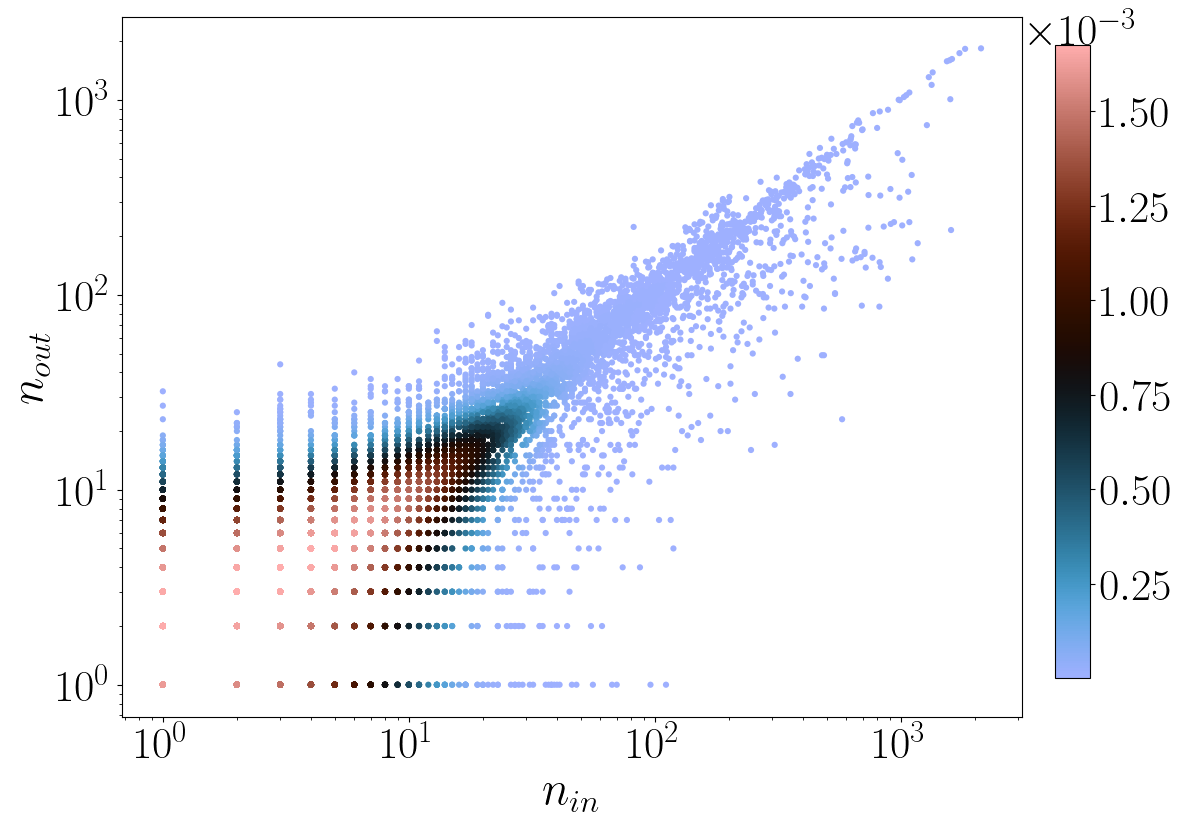

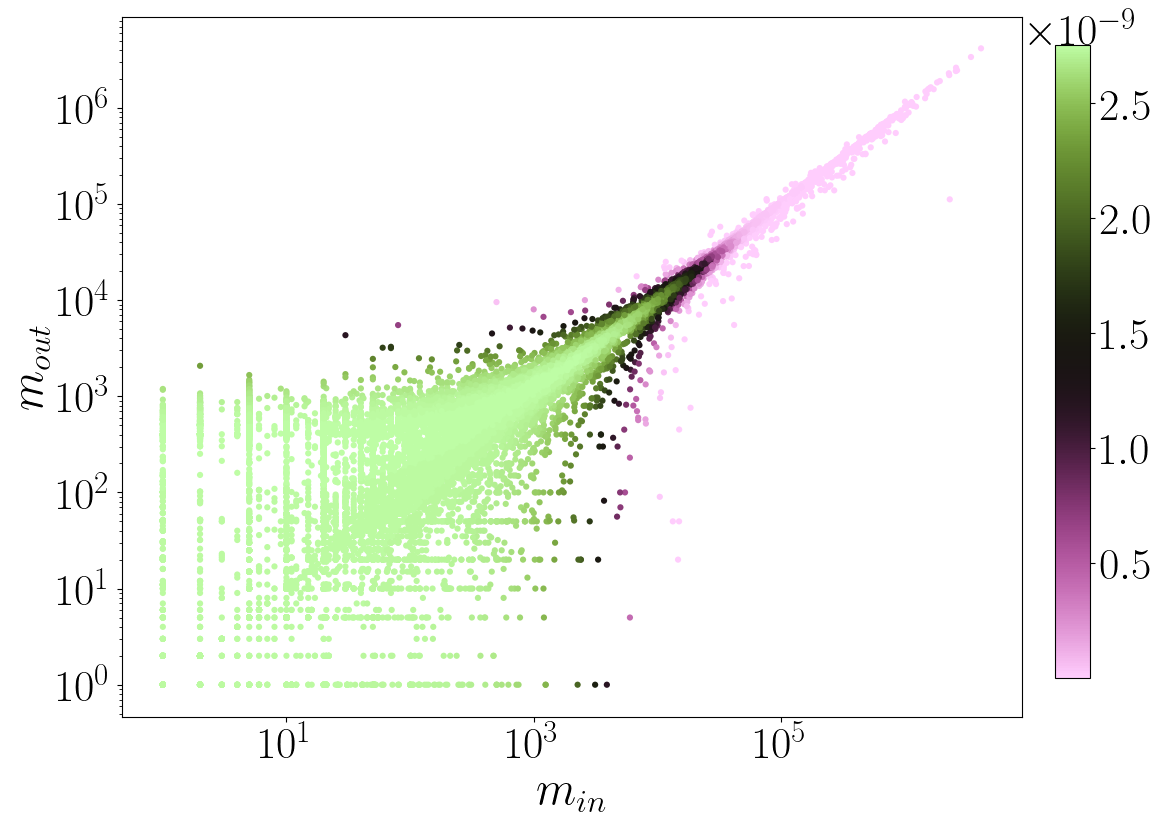

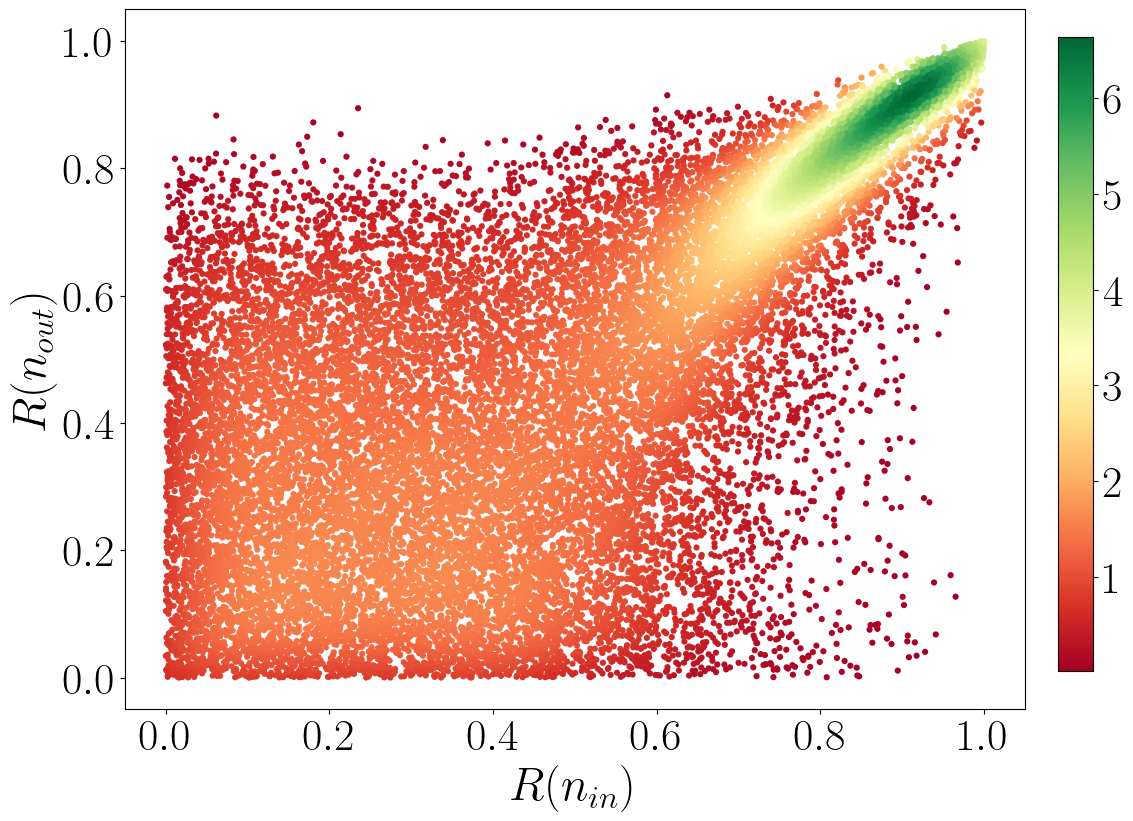

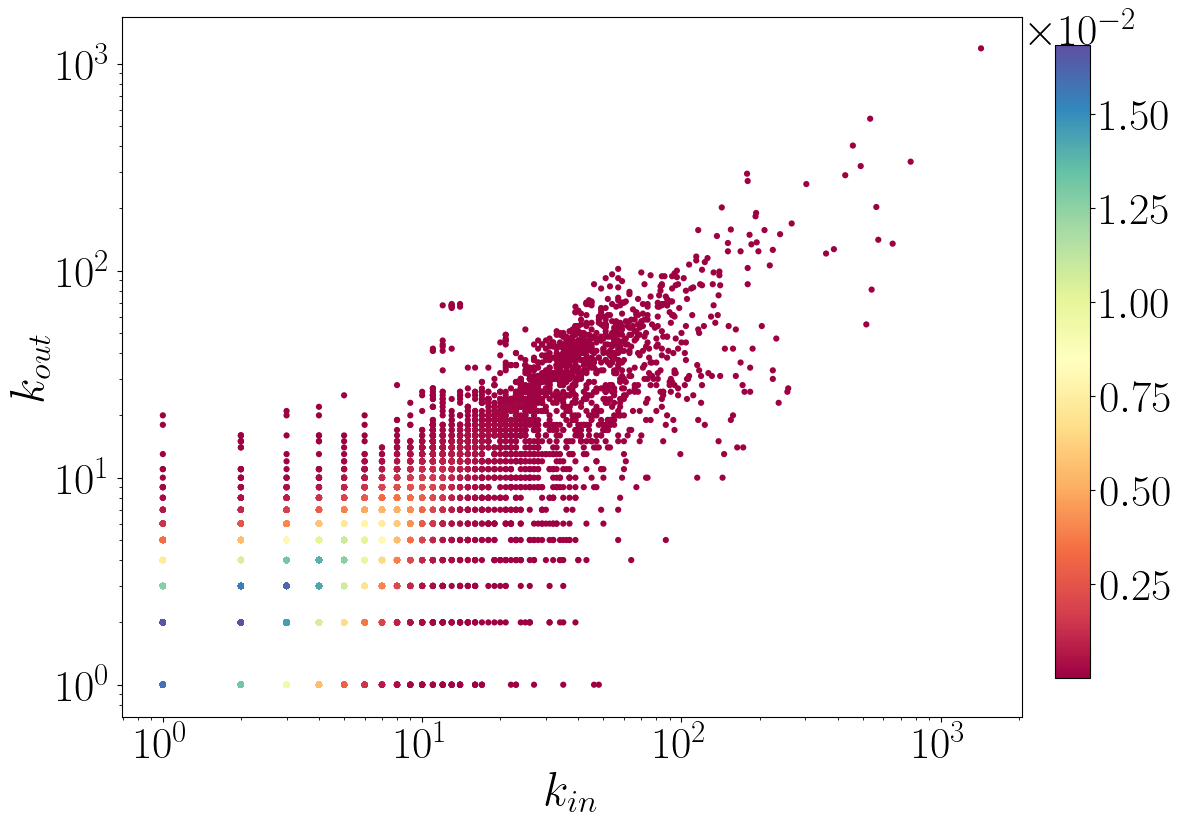

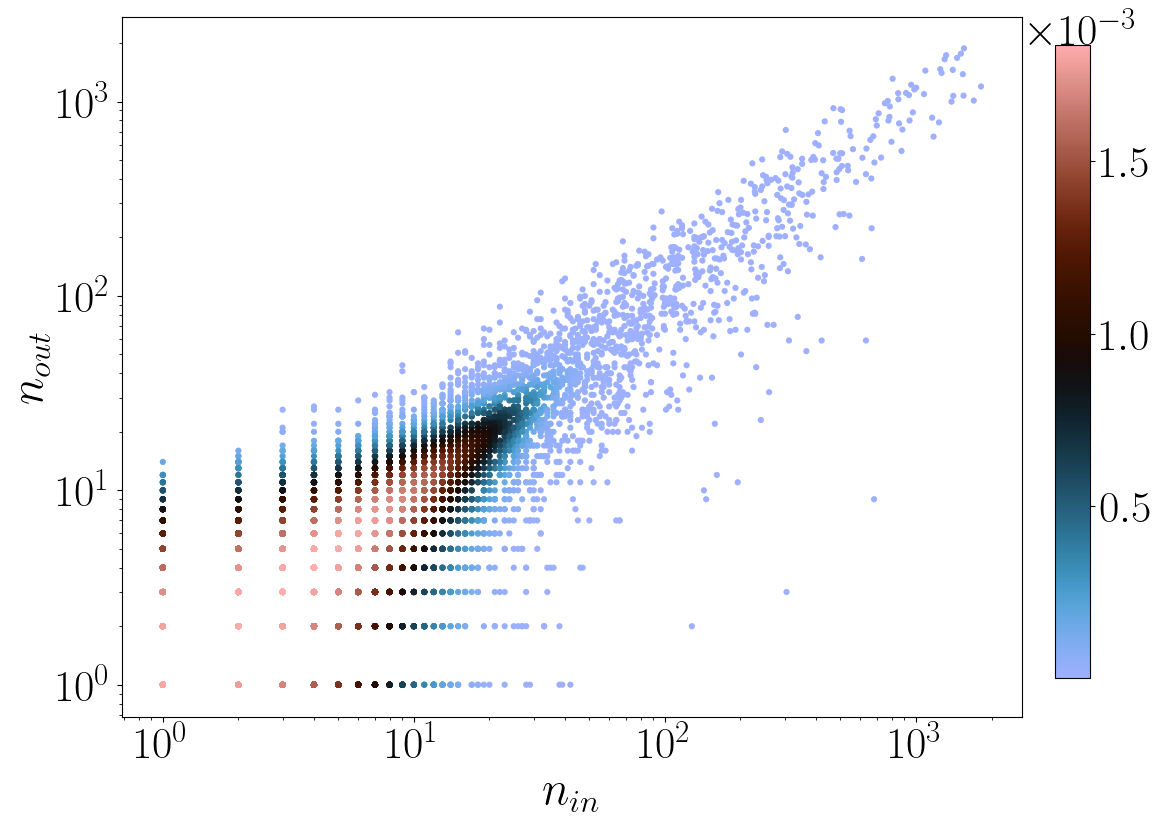

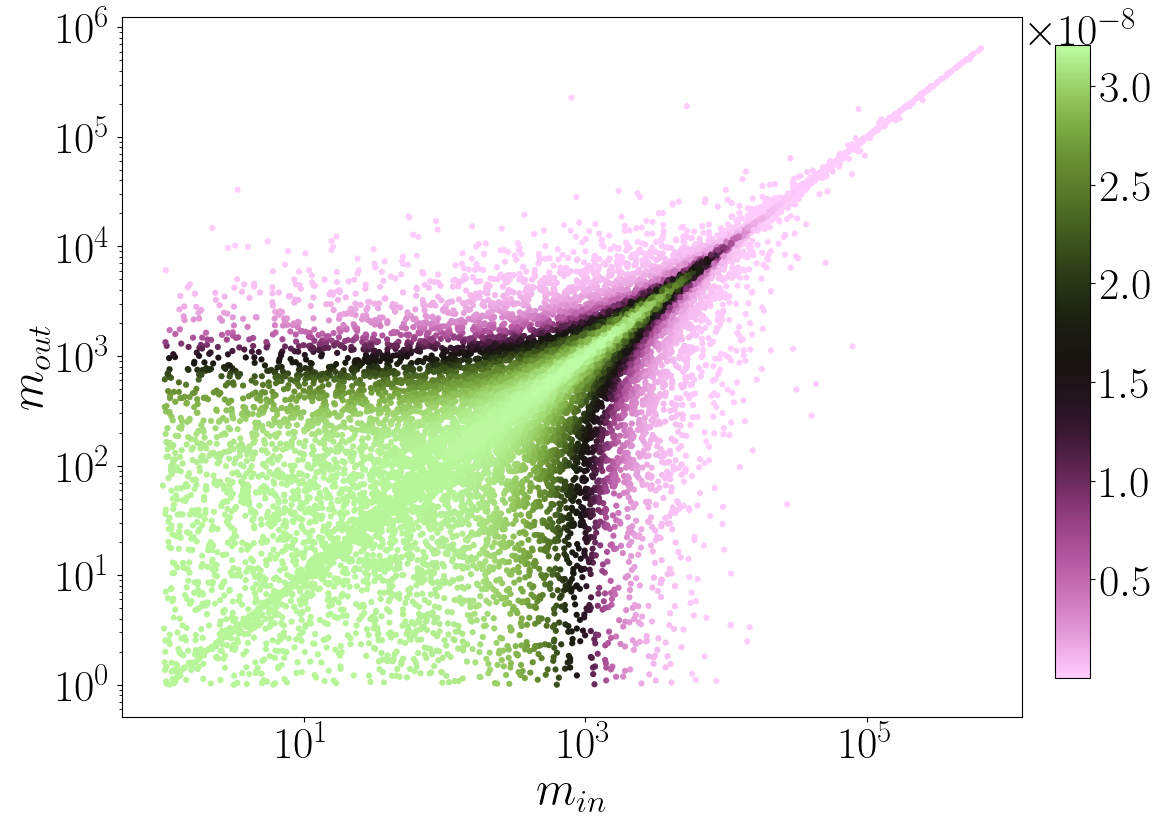

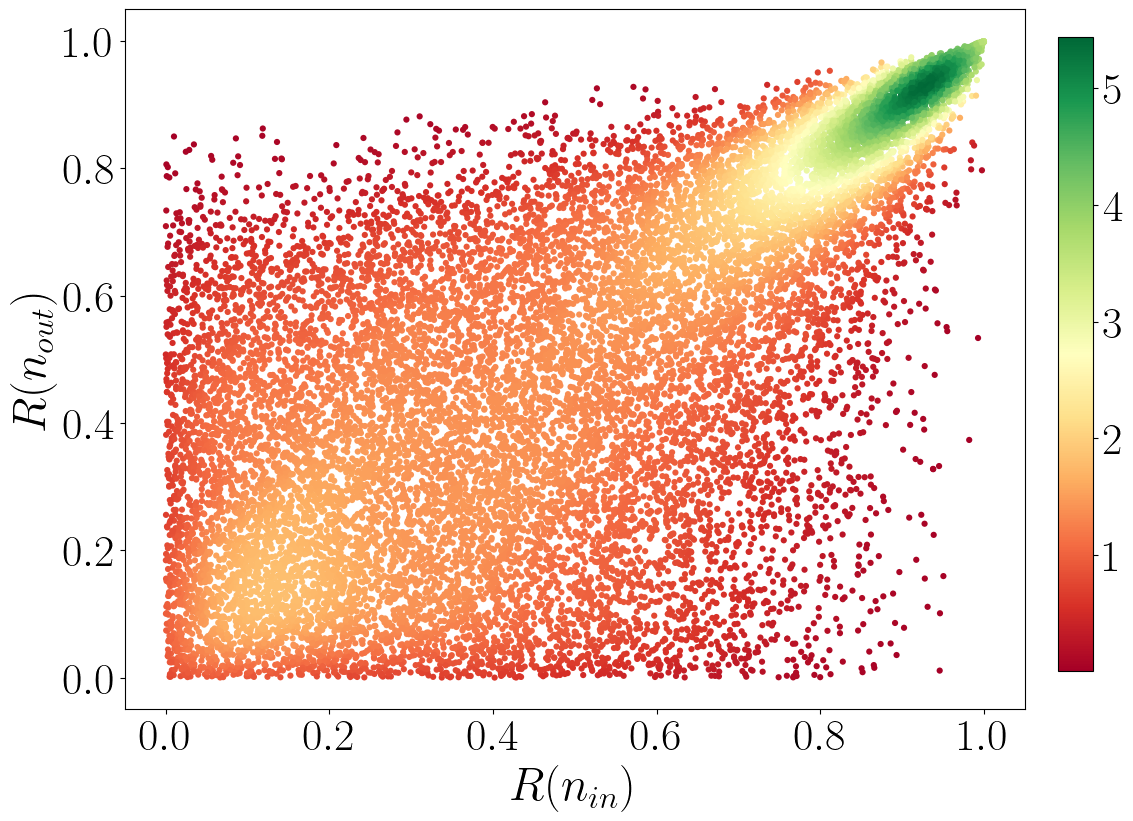

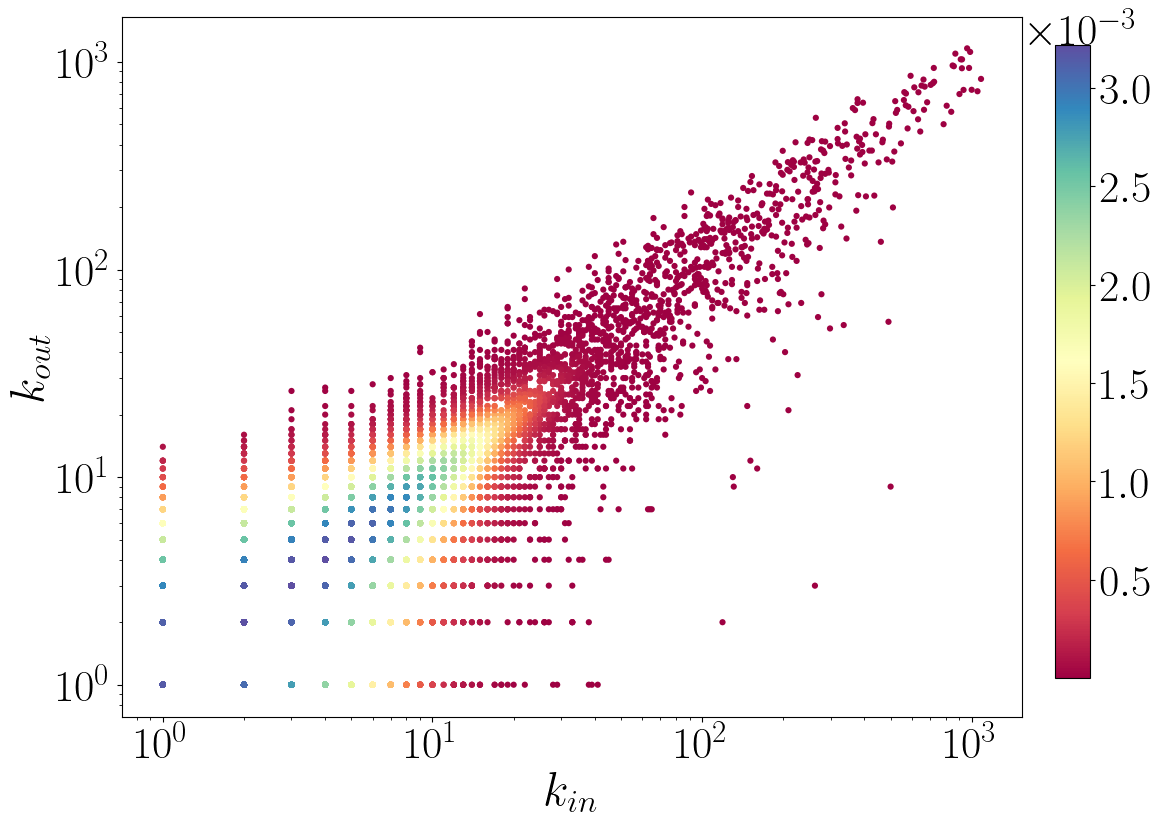

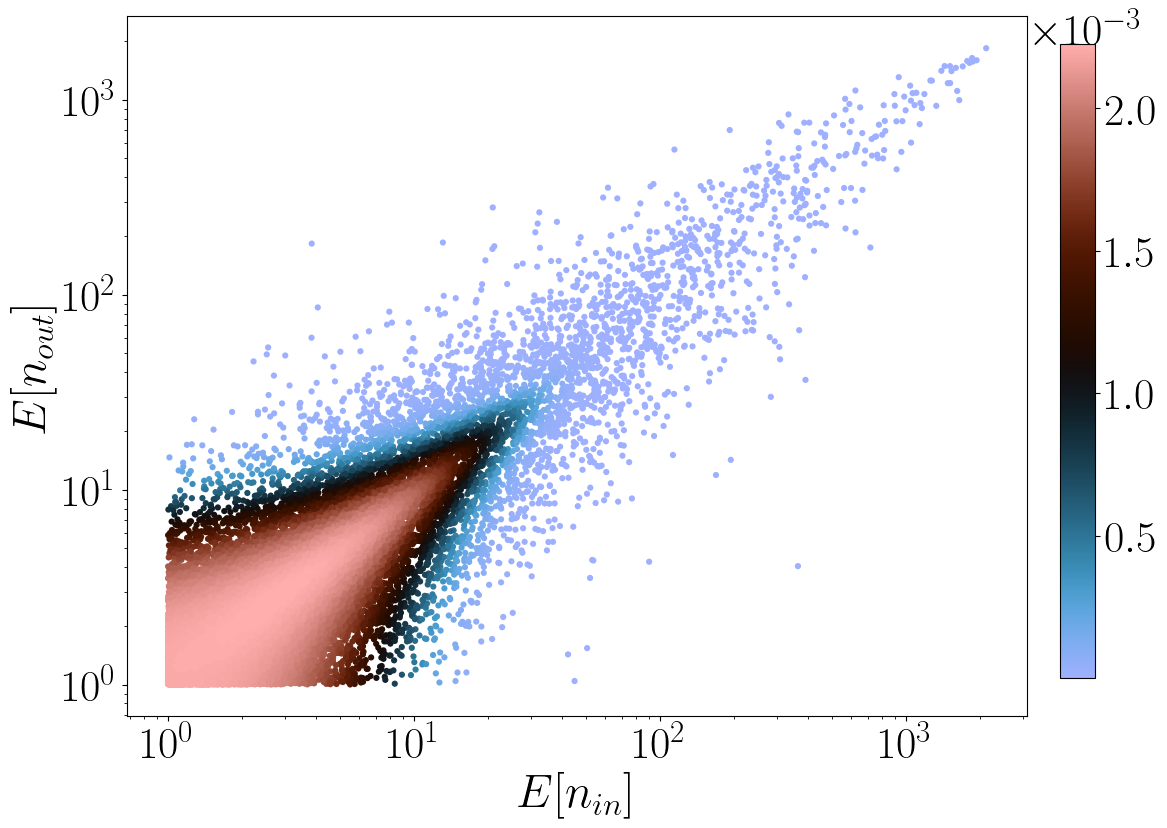

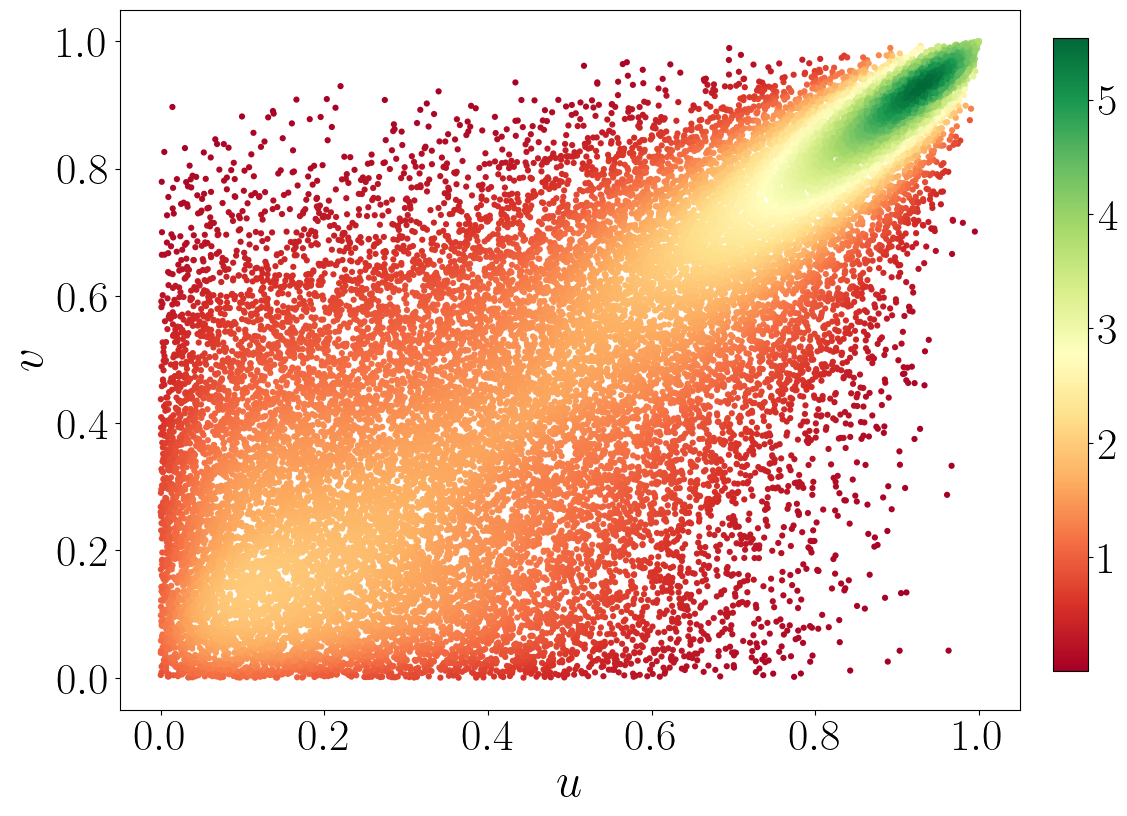

In [ ]:
#* SAFE NORMAL * THI SCRIPT WORKS WELL, GEENRATES GOOD QUALITY FIGURES
mpl.rcdefaults()
N=10
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=N+22)          # controls default text sizes
plt.rc('axes', titlesize=N+24)     # fontsize of the axes title
plt.rc('axes', labelsize=N+24)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('legend', fontsize=N+22)    # legend fontsize
plt.rc('figure', titlesize=N+24)   # fontsize of the figure title

# --------------------------------------------------
# FIXED AXES GEOMETRY (edit numbers if needed)
# --------------------------------------------------
ax_w, ax_h = 9, 7                 # axes size in inches
left, right = 1.2, 1.5            # margins in inches
bottom, top = 1.2, 0.6            # margins in inches


# #to make just specific plots
# metrics = ["in_deg-out_deg"]
striter = iter(string.ascii_lowercase)
equal = False
dot_size = 20

fig_w = ax_w + left + right
fig_h = ax_h + bottom + top


for a,b in tqdm(product(typos,metrics)):

    # --------------------------------------------------
    # DATA
    # --------------------------------------------------
    typo = a
    simu_id = metadata.query(QUERY).iloc[0].simulation_id
    metric = b
    try:
        cfg = (nodes_cfg[metric] 
            if typo == 'nodes' 
            else shared[metric])
            

        tag = "s=NA__b=NA" if typo == "sarafu" else query_to_tag(QUERY)
        starter = "sarafu" if typo == "sarafu" else f"{typo}__{BATCH}__{simu_id}"
        fname = f"{starter}__metric={metric}__{tag}.pkl"

        fpath = (
            SARAFU_PICKLED / "kde" / fname
            if typo == "sarafu"
            else PICKLED / BATCH / "kde" / fname
        )

        disp = 'single'
        save_name = (
            f"{disp}__metric={metric}__{typo}"
            if typo == "sarafu"
            else f"{disp}__metric={metric}__{typo}__{tag}"
        )

        cmap = cfg['cmap']
        loglog = cfg['loglog']
        xlabel, ylabel = cfg['labels']

        k = pickle.load(open(fpath, "rb"))
   

        fig = plt.figure(figsize=(fig_w, fig_h))

        divider = Divider(
            fig, (0, 0, 1, 1),
            horizontal=[
                Size.Fixed(left),
                Size.Fixed(ax_w),
                Size.Fixed(right),
            ],
            vertical=[
                Size.Fixed(bottom),
                Size.Fixed(ax_h),
                Size.Fixed(top),
            ],
        )

        ax = fig.add_axes(
            divider.get_position(),
            axes_locator=divider.new_locator(nx=1, ny=1)
        )



        # --------------------------------------------------
        # SCATTER PLOT (data-agnostic)
        # --------------------------------------------------
        # x, y, z must be defined by the caller (loop-safe)
        sc = ax.scatter(
            k.x, k.y,
            c=k.z,
            cmap=cmap,
            s=dot_size,
            linewidths=0,
            rasterized=True,
        )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if equal:
            ax.set_aspect("equal")

        if loglog:
            ax.loglog()


        # --------------------------------------------------
        # COLORBAR (fixed position, does NOT resize axes)
        # --------------------------------------------------
        sf = mticker.ScalarFormatter(useMathText=True)
        sf.set_powerlimits((0, 0))

        cax = fig.add_axes([0.9, 0.18, 0.03, 0.72])  # figure fractions

        cb = fig.colorbar(sc, cax=cax, format=sf)
        cb.set_label(None)

        ot = cb.ax
        ot.yaxis.get_offset_text().set_x(2.5)
        ot.yaxis.get_offset_text().set_y(5)


        
        # --------------------------------------------------
        # SAVE (NO tight)
        # --------------------------------------------------
        test = 1
        if test:
            name = next(striter)
            print(name, FIGURES/f"{name}.pdf")
            fig.savefig(FIGURES/"tests"/f"{name}.pdf", 
                        format = 'pdf', 
                        bbox_inches=None, 
                        pad_inches=0.0)
        else:
            fig.savefig(FIGURES / f"{save_name}.pdf", 
                    format = 'pdf', 
                    bbox_inches=None, 
                    pad_inches=0.0)
        # plt.close(fig)
    except FileNotFoundError:
        continue          # salta questo file e vai avanti
    except Exception as e:
        print(e)
        continue

0it [00:00, ?it/s]

huge_nolabels_a /home/claudio/papers/adtxns_paper/figures/kde/huge_nolabels_a.pdf


1it [00:00,  1.55it/s]

huge_nolabels_b /home/claudio/papers/adtxns_paper/figures/kde/huge_nolabels_b.pdf


2it [00:01,  1.72it/s]

...

huge_nolabels_i /home/claudio/papers/adtxns_paper/figures/kde/huge_nolabels_i.pdf


9it [00:04,  2.06it/s]

'vol_in-vol_out'
huge_nolabels_j /home/claudio/papers/adtxns_paper/figures/kde/huge_nolabels_j.pdf


12it [00:04,  2.48it/s]


'in_deg-out_deg'


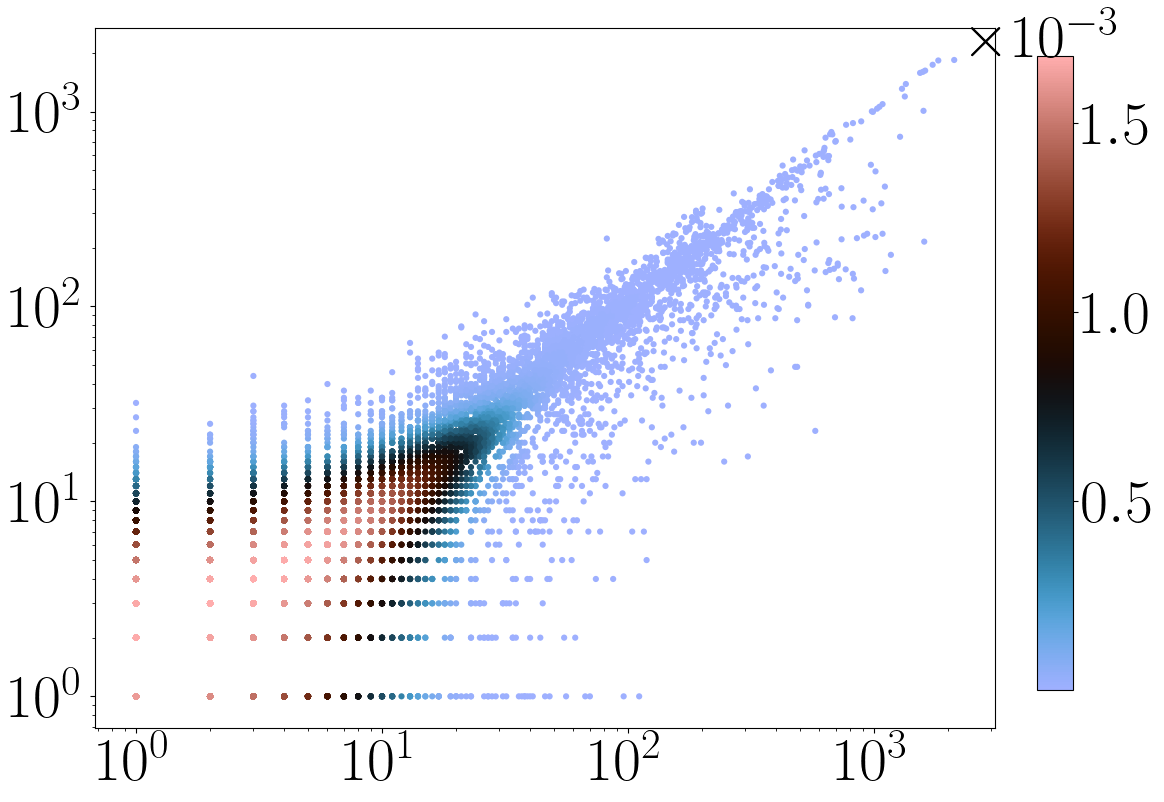

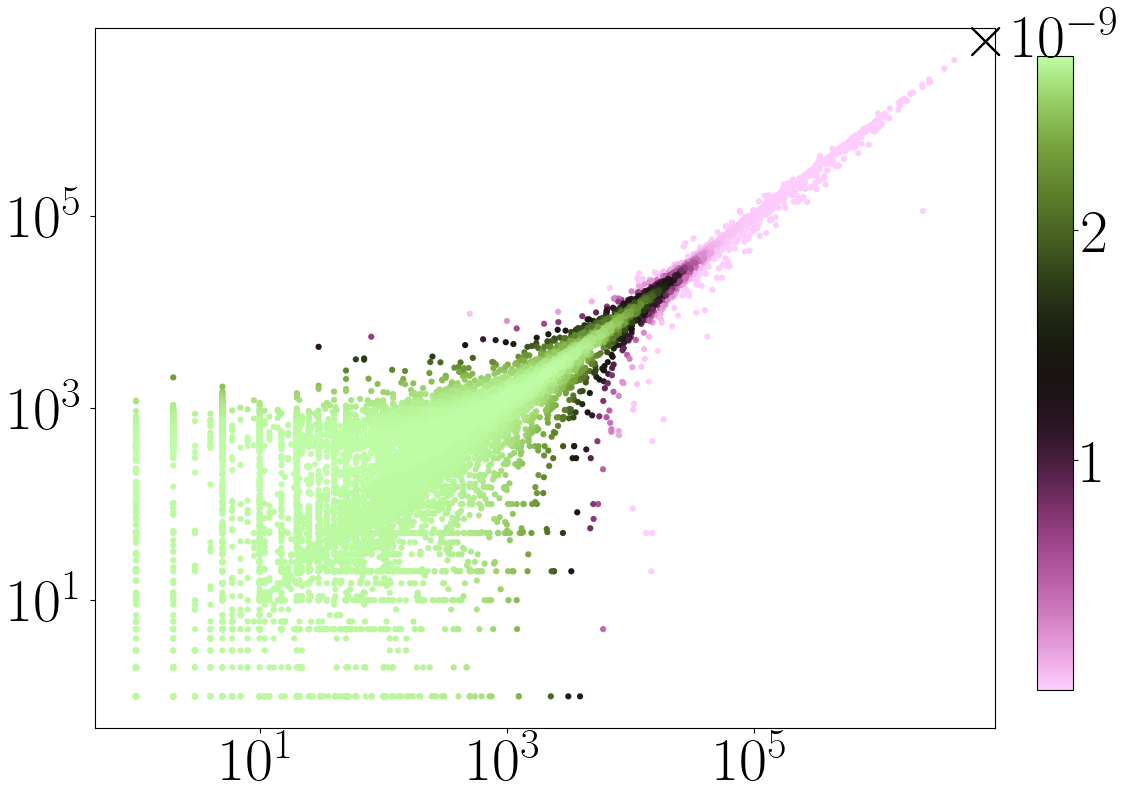

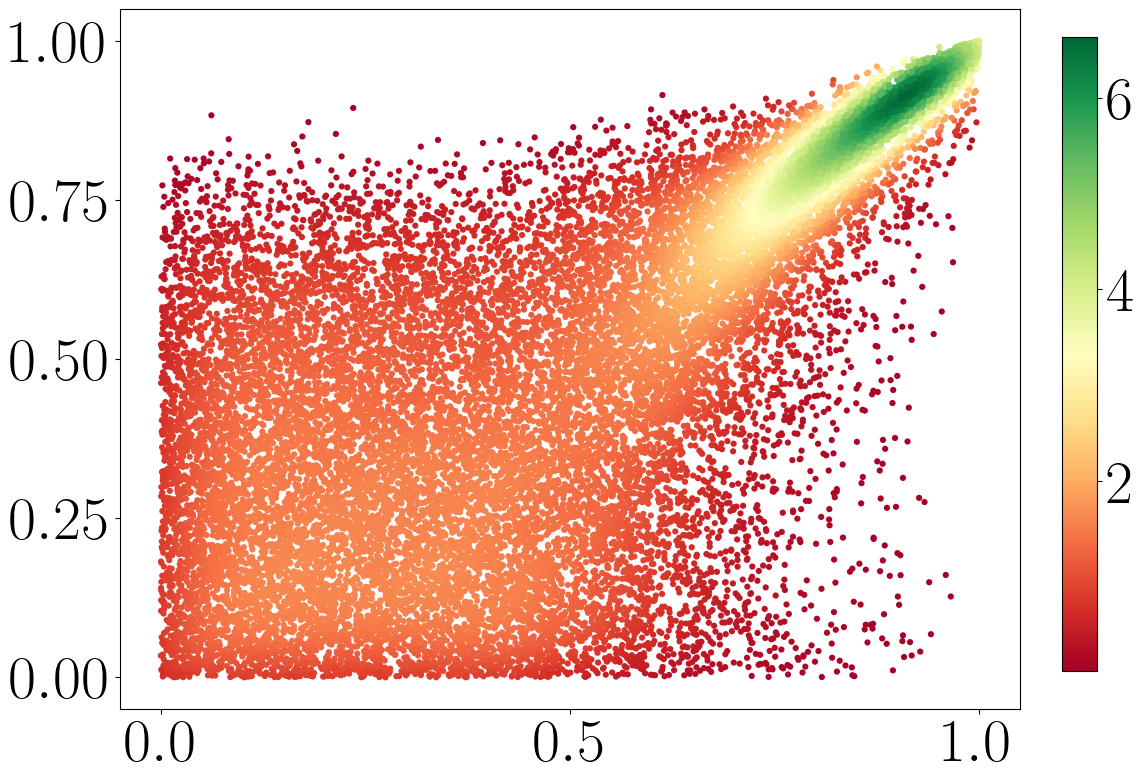

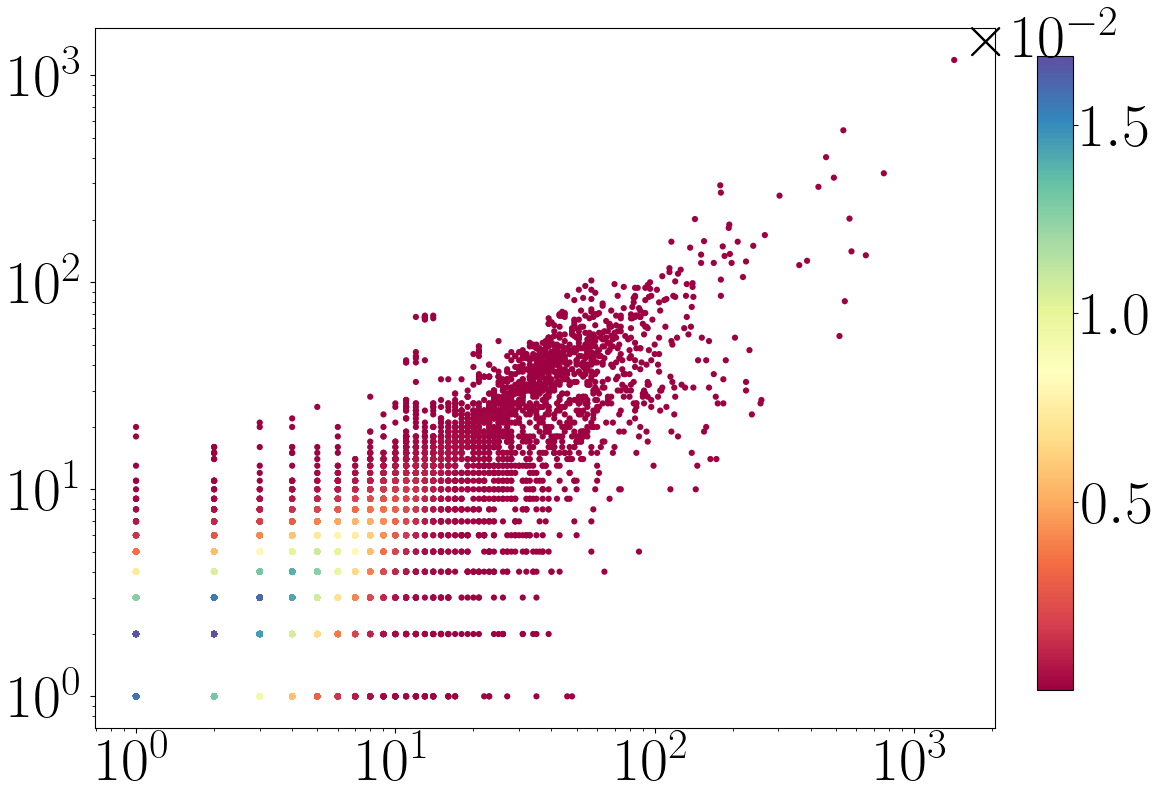

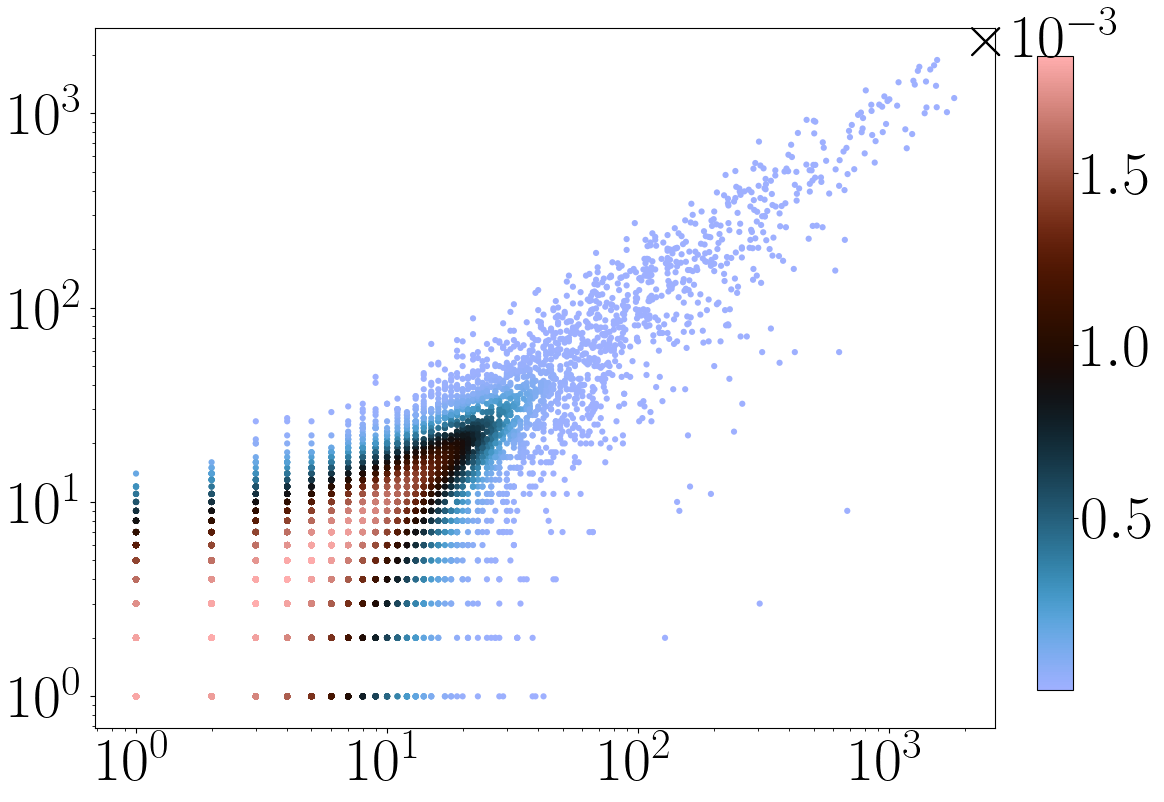

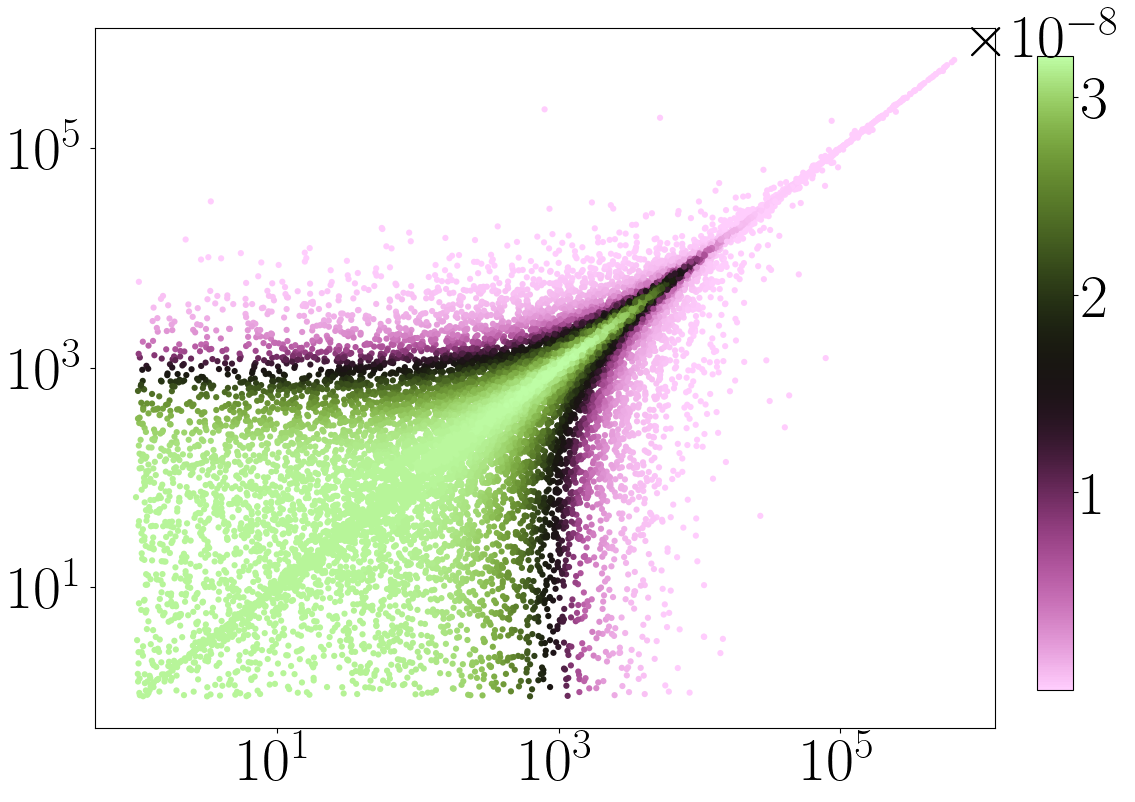

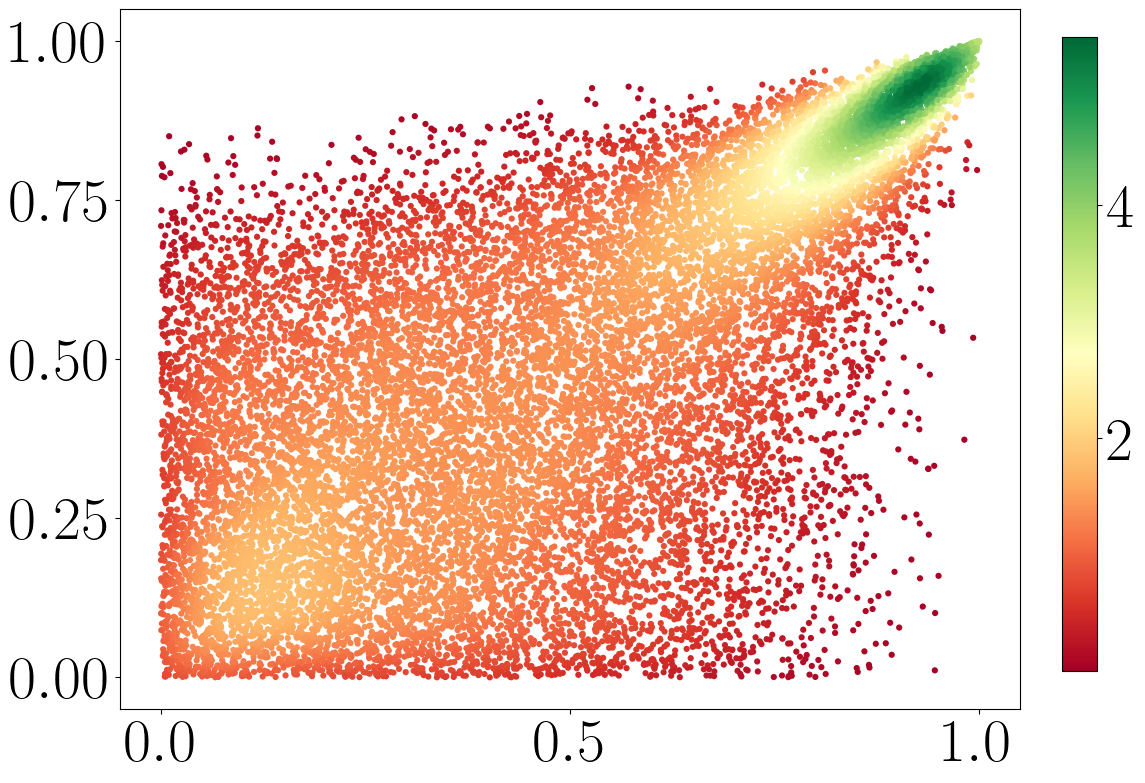

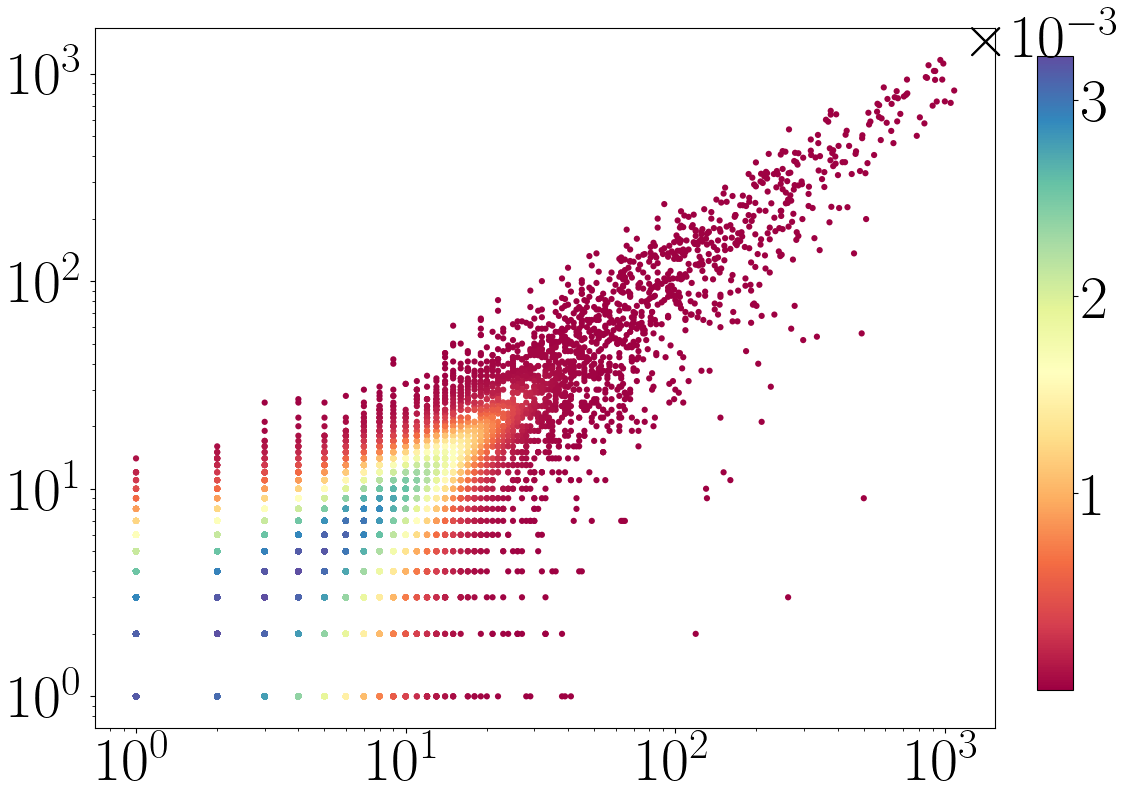

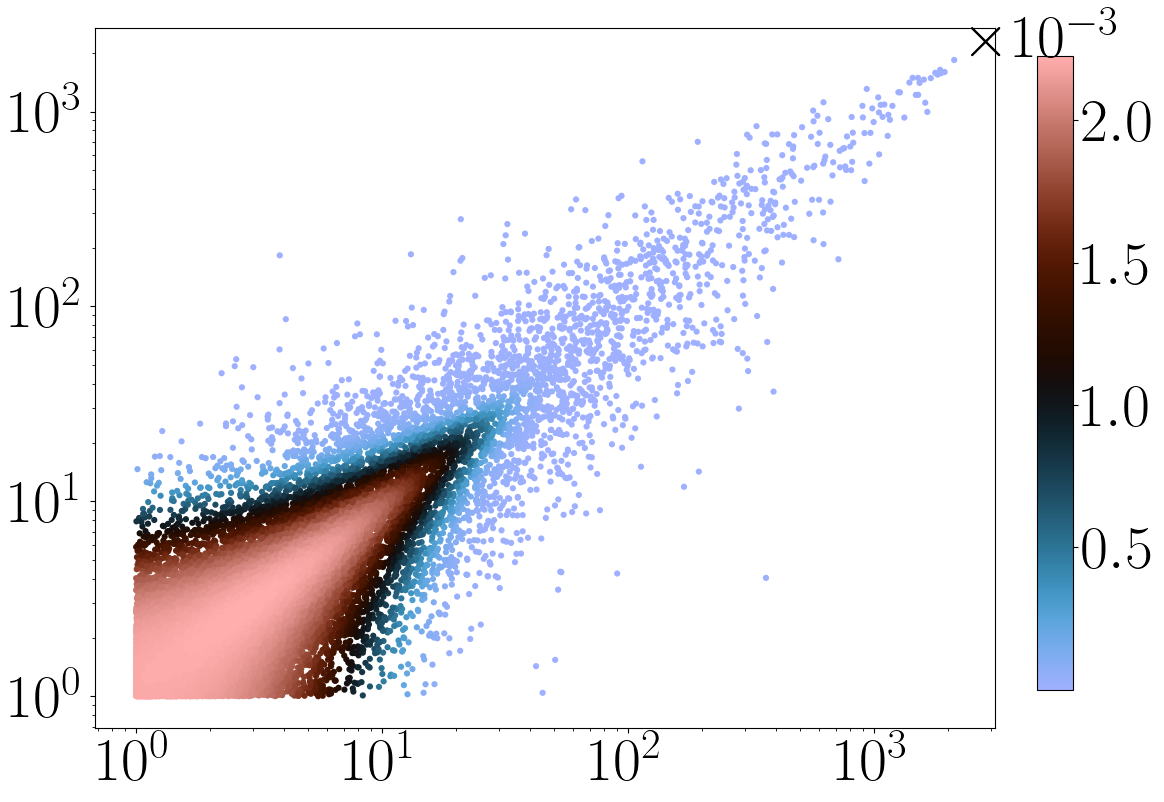

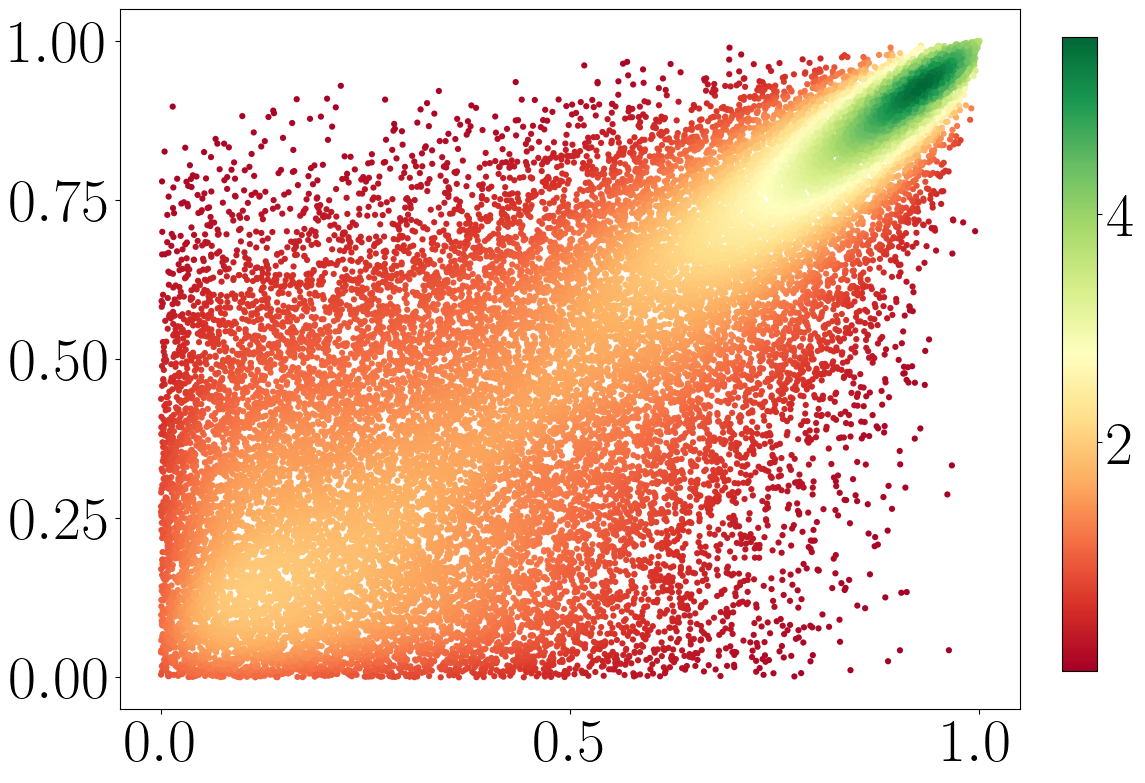

In [ ]:
""" THIS SCRIPT GENERATES FIGURES WITH MAGNIFIED FONTS, AND NO AXES LABELS. IT REQUIRES A LOT OF MICRO-MANAGEMENT OF THE MARGINS IN ORDER TO GET THE FIGURES NOT TO BE CLIPPED"""
mpl.rcdefaults()
N=22
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=N+22)          # controls default text sizes
plt.rc('axes', titlesize=N+24)     # fontsize of the axes title
plt.rc('axes', labelsize=N+24)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('legend', fontsize=N+22)    # legend fontsize
plt.rc('figure', titlesize=N+24)   # fontsize of the figure title

#huge
#* BIGGER SIZE
# --------------------------------------------------
# FIXED AXES GEOMETRY (edit numbers if needed)
# --------------------------------------------------
ax_w, ax_h = 9, 7                 # axes size in inches
left, right = 1.2, 1.6            # margins in inches
bottom, top = 1.2, 0.6            # margins in inches


# #to make just specific plots
# metrics = ["in_deg-out_deg"]
striter = iter(string.ascii_lowercase)
equal = False
dot_size = 20

fig_w = ax_w + left + right
fig_h = ax_h + bottom + top


for a,b in tqdm(product(typos,metrics)):

    # --------------------------------------------------
    # DATA
    # --------------------------------------------------
    typo = a
    simu_id = metadata.query(QUERY).iloc[0].simulation_id
    metric = b
    try:
        cfg = (nodes_cfg[metric] 
            if typo == 'nodes' 
            else shared[metric])
            

        tag = "s=NA__b=NA" if typo == "sarafu" else query_to_tag(QUERY)
        starter = "sarafu" if typo == "sarafu" else f"{typo}__{BATCH}__{simu_id}"
        fname = f"{starter}__metric={metric}__{tag}.pkl"

        fpath = (
            SARAFU_PICKLED / "kde" / fname
            if typo == "sarafu"
            else PICKLED / BATCH / "kde" / fname
        )

        disp = 'single'
        save_name = (
            f"{disp}__metric={metric}__{typo}"
            if typo == "sarafu"
            else f"{disp}__metric={metric}__{typo}__{tag}"
        )

        cmap = cfg['cmap']
        loglog = cfg['loglog']
        xlabel, ylabel = cfg['labels']

        k = pickle.load(open(fpath, "rb"))
   

        fig = plt.figure(figsize=(fig_w, fig_h))

        divider = Divider(
            fig, (0, 0, 1, 1),
            horizontal=[
                Size.Fixed(left),
                Size.Fixed(ax_w),
                Size.Fixed(right),
            ],
            vertical=[
                Size.Fixed(bottom),
                Size.Fixed(ax_h),
                Size.Fixed(top),
            ],
        )

        ax = fig.add_axes(
            divider.get_position(),
            axes_locator=divider.new_locator(nx=1, ny=1)
        )



        # --------------------------------------------------
        # SCATTER PLOT (data-agnostic)
        # --------------------------------------------------
        # x, y, z must be defined by the caller (loop-safe)
        sc = ax.scatter(
            k.x, k.y,
            c=k.z,
            cmap=cmap,
            s=dot_size,
            linewidths=0,
            rasterized=True,
        )

        # ax.set_xlabel(xlabel)
        # ax.set_ylabel(ylabel)
        if equal:
            ax.set_aspect("equal")

        if loglog:
            ax.loglog()


        # --------------------------------------------------
        # COLORBAR (fixed position, does NOT resize axes)
        # --------------------------------------------------
        sf = mticker.ScalarFormatter(useMathText=True)
        sf.set_powerlimits((0, 0))

        cax = fig.add_axes([0.9, 0.18, 0.03, 0.72])  # figure fractions

        cb = fig.colorbar(sc, cax=cax, format=sf)
        cb.set_label(None)

        ot = cb.ax
        ot.yaxis.get_offset_text().set_x(2.5)
        ot.yaxis.get_offset_text().set_y(5)


        
        # --------------------------------------------------
        # SAVE (NO tight)
        # --------------------------------------------------
        test = 1
        if test:
            name = "huge_nolabels_"+next(striter)
            print(name, FIGURES/f"{name}.pdf")
            fig.savefig(FIGURES/"tests"/f"{name}.pdf", 
                        format = 'pdf', 
                        bbox_inches=None, 
                        pad_inches=0.0)
        else:
            fig.savefig(FIGURES / f"{save_name}.pdf", 
                    format = 'pdf', 
                    bbox_inches=None, 
                    pad_inches=0.0)
        # plt.close(fig)
    except FileNotFoundError:
        continue          # salta questo file e vai avanti
    except Exception as e:
        print(e)
        continue

In [ ]:
"""THIS SCRIPT SHOULD GENERATE FIGURES ON SQUARED AXIS (SET_ASPET("equal")). IT DOES NOT WORK PROPERLY SINCE THE COLORBAR GETS MISSPLACED. IT REQUIRES REFACTORING OF         
        cax = fig.add_axes([0.9, 0.18, 0.03, 0.72])  # figure fractions
IN ORDER TO DYNAMICALLY POSITION THE COLORBAR 
"""
# --------------------------------------------------
# FIXED AXES GEOMETRY (edit numbers if needed)
# --------------------------------------------------
ax_w, ax_h = 9, 7                 # axes size in inches
left, right = 1.2, 1.5            # margins in inches
bottom, top = 1.2, 0.6            # margins in inches


# #to make just specific plots
# metrics = ["in_deg-out_deg"]
striter = iter(string.ascii_lowercase)
equal = True
dot_size = 20

if equal:
    left, right = 1.0, 1.5            # margins in inches
    bottom, top = 1.2, 1.8            # margins in inches

fig_w = ax_w + left + right
fig_h = ax_h + bottom + top


for a,b in tqdm(product(typos,metrics)):

    # --------------------------------------------------
    # DATA
    # --------------------------------------------------
    typo = a
    simu_id = metadata.query(QUERY).iloc[0].simulation_id
    metric = b
    try:
        cfg = (nodes_cfg[metric] 
            if typo == 'nodes' 
            else shared[metric])
            

        tag = "s=NA__b=NA" if typo == "sarafu" else query_to_tag(QUERY)
        starter = "sarafu" if typo == "sarafu" else f"{typo}__{BATCH}__{simu_id}"
        fname = f"{starter}__metric={metric}__{tag}.pkl"

        fpath = (
            SARAFU_PICKLED / "kde" / fname
            if typo == "sarafu"
            else PICKLED / BATCH / "kde" / fname
        )

        disp = 'single'
        save_name = (
            f"{disp}__metric={metric}__{typo}"
            if typo == "sarafu"
            else f"{disp}__metric={metric}__{typo}__{tag}"
        )

        cmap = cfg['cmap']
        loglog = cfg['loglog']
        xlabel, ylabel = cfg['labels']

        k = pickle.load(open(fpath, "rb"))
   

        fig = plt.figure(figsize=(fig_w, fig_h))

        divider = Divider(
            fig, (0, 0, 1, 1),
            horizontal=[
                Size.Fixed(left),
                Size.Fixed(ax_w),
                Size.Fixed(right),
            ],
            vertical=[
                Size.Fixed(bottom),
                Size.Fixed(ax_h),
                Size.Fixed(top),
            ],
        )

        ax = fig.add_axes(
            divider.get_position(),
            axes_locator=divider.new_locator(nx=1, ny=1)
        )



        # --------------------------------------------------
        # SCATTER PLOT (data-agnostic)
        # --------------------------------------------------
        # x, y, z must be defined by the caller (loop-safe)
        sc = ax.scatter(
            k.x, k.y,
            c=k.z,
            cmap=cmap,
            s=dot_size,
            linewidths=0,
            rasterized=True,
        )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if equal:
            ax.set_aspect("equal")

        if loglog:
            ax.loglog()


        # --------------------------------------------------
        # COLORBAR (fixed position, does NOT resize axes)
        # --------------------------------------------------
        sf = mticker.ScalarFormatter(useMathText=True)
        sf.set_powerlimits((0, 0))

        cax = fig.add_axes([0.9, 0.18, 0.03, 0.72])  # figure fractions

        cb = fig.colorbar(sc, cax=cax, format=sf)
        cb.set_label(None)

        ot = cb.ax
        ot.yaxis.get_offset_text().set_x(2.5)
        ot.yaxis.get_offset_text().set_y(5)


        
        # --------------------------------------------------
        # SAVE (NO tight)
        # --------------------------------------------------
        test = 1
        if test:
            name = "huge_equal_"+next(striter)
            print(name, FIGURES/f"{name}.pdf")
            fig.savefig(FIGURES/"tests"/f"{name}.pdf", 
                        format = 'pdf', 
                        bbox_inches=None, 
                        pad_inches=0.0)
        else:
            fig.savefig(FIGURES / f"{save_name}.pdf", 
                    format = 'pdf', 
                    bbox_inches=None, 
                    pad_inches=0.0)
        # plt.close(fig)
    except FileNotFoundError:
        continue          # salta questo file e vai avanti
    except Exception as e:
        print(e)
        continue

In [75]:
# --------------------------------------------------
# FIXED AXES GEOMETRY (each subplot is exactly 9x7 inches)
# --------------------------------------------------
ax_w, ax_h = 9, 7                 # EACH subplot axes size (inches)

left, right = 1.5, 1.5            # outer margins (inches)
bottom, top = 1.5, 0.6            # outer margins (inches)

hgap = 0.8                        # gap between the 2 columns (inches)

# total figure size for 1x2 layout
fig_w = left + ax_w + hgap + ax_w + right
fig_h = bottom + ax_h + top

# pick 1 metric and exactly 2 typos (you said you will control this)
# choose exactly 1 metric and 2 typos externally (you said you'll do it)
metrics = ["in_deg-out_deg","tx_in-tx_out",'vol_in-vol_out']
typos = ["simulation", "sarafu"]   # fix your quotes
labels = {"sarafu":"(a)",
          "simulation":'(b)'}

for metric in tqdm(metrics):

    # --------------------------------------------------
    # one 1x2 figure per metric
    # --------------------------------------------------
    fig = plt.figure(figsize=(fig_w, fig_h))

    divider = Divider(
        fig, (0, 0, 1, 1),
        horizontal=[
            Size.Fixed(left),
            Size.Fixed(ax_w),     # left axes
            Size.Fixed(hgap),     # gap
            Size.Fixed(ax_w),     # right axes
            Size.Fixed(right),
        ],
        vertical=[
            Size.Fixed(bottom),
            Size.Fixed(ax_h),
            Size.Fixed(top),
        ],
    )

    ax_left  = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=1, ny=1))
    ax_right = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=3, ny=1))

    axes_by_typo = {
        typos[0]: ax_left,
        typos[1]: ax_right,
    }

    # --------------------------------------------------
    # plot each typo into its column
    # --------------------------------------------------
    for typo in typos:

        ax = axes_by_typo[typo]

        simu_id = metadata.query(QUERY).iloc[0].simulation_id
        cfg = (nodes_cfg[metric] if typo == "nodes" else shared[metric])

        tag = "s=NA__b=NA" if typo == "sarafu" else query_to_tag(QUERY)
        starter = "sarafu" if typo == "sarafu" else f"{typo}__{BATCH}__{simu_id}"
        fname = f"{starter}__metric={metric}__{tag}.pkl"

        fpath = (
            SARAFU_PICKLED / "kde" / fname
            if typo == "sarafu"
            else PICKLED / BATCH / "kde" / fname
        )

        cmap = cfg["cmap"]
        loglog = cfg["loglog"]
        xlabel, ylabel = cfg["labels"]

        equal = False
        dot_size = 20

        try:
            k = pickle.load(open(fpath, "rb"))
        except FileNotFoundError:
            continue

        sc = ax.scatter(
            k.x, k.y,
            c=k.z,
            cmap=cmap,
            s=dot_size,
            linewidths=0
        )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.text(0.9,0.9,labels[typo])

        if equal:
            ax.set_aspect("equal")
        if loglog:
            ax.loglog()

        # --------------------------------------------------
        # colorbar for THIS subplot, placed in its own fixed slot
        # (one colorbar per column, fixed inches via divider)
        # --------------------------------------------------
        sf = mticker.ScalarFormatter(useMathText=True)
        sf.set_powerlimits((0, 0))

        # Add a cax INSIDE the right margin of each subplot column (fixed inches):
        # We create a narrow colorbar axes next to the subplot by using figure fractions.
        # Simple + stable: hard-code per-column cax positions.
        if typo == typos[0]:   # left column
            cax = fig.add_axes([0.46, 0.18, 0.015, 0.72])
        else:                  # right column
            cax = fig.add_axes([0.93, 0.18, 0.015, 0.72])

        cb = fig.colorbar(sc, cax=cax, format=sf)
        cb.set_label(None)

    # --------------------------------------------------
    # SAVE one combined 1x2 figure
    # --------------------------------------------------
    tag = query_to_tag(QUERY)
    save_name = f"1x2__metric={metric}__typos={typos[0]}-{typos[1]}__{tag}.pdf"
    fig.savefig(FIGURES / save_name, format="pdf", bbox_inches=None, pad_inches=0.0)
    plt.close(fig)


100%|██████████| 3/3 [00:12<00:00,  4.09s/it]


 67%|██████▋   | 2/3 [00:10<00:05,  5.32s/it]


IndexError: list index out of range

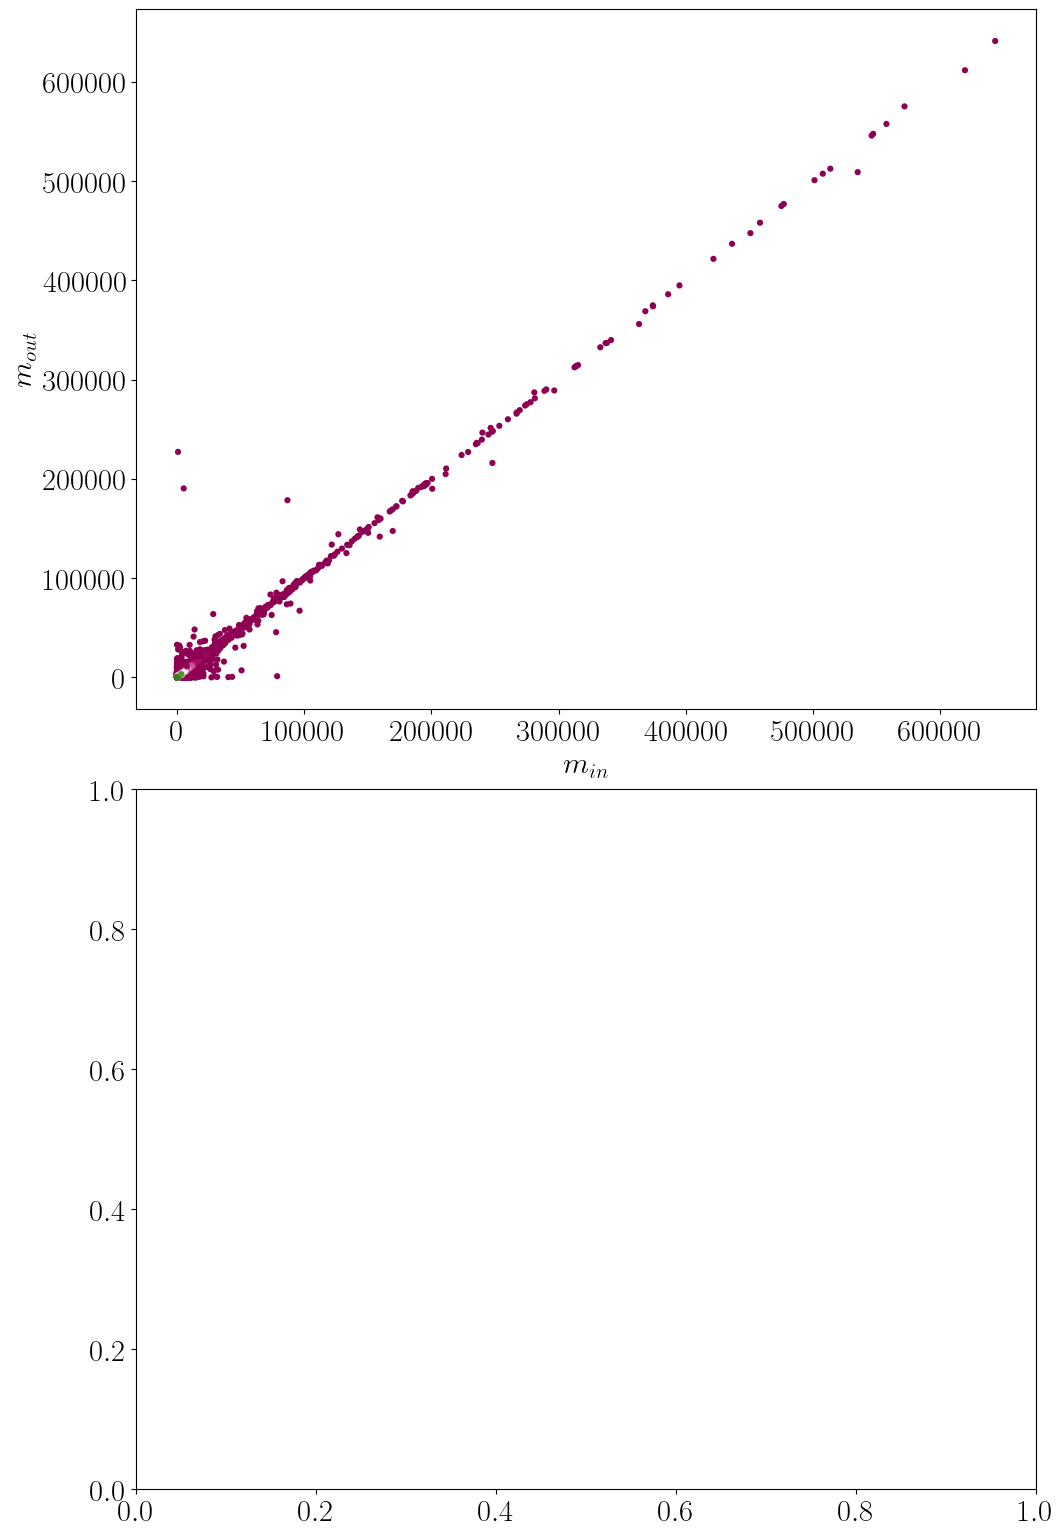

In [ ]:

# # --------------------------------------------------
# # FIXED AXES GEOMETRY (single axes size)
# # --------------------------------------------------
# ax_w, ax_h = 9, 7                 # each axes size in inches
# left, right = 1.0, 1.5            # margins in inches
# bottom, top = 1.2, 0.6            # margins in inches

# # vertical gap between the two panels (inches)
# vgap = 0.8

# # total figure size for 2x1 (two axes stacked)
# fig_w = left + ax_w + right
# fig_h = bottom + ax_h + vgap + ax_h + top

# # choose exactly 1 metric and 2 typos externally (you said you'll do it)
# metrics = ["in_deg-out_deg","tx_in-tx_out",'vol_in-vol_out']
# typos = ["simulation", "sarafu"]   # fix your quotes
# labels = {"sarafu":"(a)",
#           "simulation":'(b)'}

# label_counter = 0
# for metric in tqdm(metrics):

#     # --------------------------------------------------
#     # create ONE 2x1 figure per metric
#     # --------------------------------------------------
#     fig = plt.figure(figsize=(fig_w, fig_h))

#     divider = Divider(
#         fig, (0, 0, 1, 1),
#         horizontal=[
#             Size.Fixed(left),
#             Size.Fixed(ax_w),
#             Size.Fixed(right),
#         ],
#         vertical=[
#             Size.Fixed(bottom),   # row 0 bottom margin
#             Size.Fixed(ax_h),     # row 0 axes height
#             Size.Fixed(vgap),     # gap
#             Size.Fixed(ax_h),     # row 1 axes height
#             Size.Fixed(top),      # top margin
#         ],
#     )

#     # bottom panel (ny=1), top panel (ny=3)
#     ax_bottom = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=1, ny=1))
#     ax_top    = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=1, ny=3))

#     axes_by_typo = {
#         typos[0]: ax_top,
#         typos[1]: ax_bottom,
#     }

#     # OPTIONAL: consistent label handling (avoid duplicated ylabels if you want)
#     # ax_top.set_xlabel("")
#     # ax_bottom.set_xlabel(xlabel)

#     # --------------------------------------------------
#     # plot the two typos into the two axes
#     # --------------------------------------------------
#     for typo in typos:

#         ax = axes_by_typo[typo]

#         simu_id = metadata.query(QUERY).iloc[0].simulation_id

#         cfg = (nodes_cfg[metric] if typo == "nodes" else shared[metric])

#         tag = "s=NA__b=NA" if typo == "sarafu" else query_to_tag(QUERY)
#         starter = "sarafu" if typo == "sarafu" else f"{typo}__{BATCH}__{simu_id}"
#         fname = f"{starter}__metric={metric}__{tag}.pkl"

#         fpath = (
#             SARAFU_PICKLED / "kde" / fname
#             if typo == "sarafu"
#             else PICKLED / BATCH / "kde" / fname
#         )

#         cmap = cfg["cmap"]
#         loglog = cfg["loglog"]
#         xlabel, ylabel = cfg["labels"]

#         equal = False
#         dot_size = 20

#         try:
#             k = pickle.load(open(fpath, "rb"))
#         except FileNotFoundError:
#             continue

#         sc = ax.scatter(
#             k.x, k.y,
#             c=k.z,
#             cmap=cmap,
#             s=dot_size,
#             linewidths=0
#         )

#         ax.set_xlabel(xlabel)
#         ax.set_ylabel(ylabel)
#         ax.text(0.9, 0.1, labels[label_counter], transform=ax.transAxes, ha="right")
#         label_counter+=1

#         if equal:
#             ax.set_aspect("equal")
#         if loglog:
#             ax.loglog()

#         # --------------------------------------------------
#         # per-axes colorbar in the RIGHT margin, fixed position
#         # (use different y for top vs bottom)
#         # --------------------------------------------------
#         sf = mticker.ScalarFormatter(useMathText=True)
#         sf.set_powerlimits((0, 0))

#         if typo == typos[0]:   # top
#             cax = fig.add_axes([0.90, 0.57, 0.03, 0.32])
#         else:                  # bottom
#             cax = fig.add_axes([0.90, 0.14, 0.03, 0.32])

#         cb = fig.colorbar(sc, cax=cax, format=sf)
#         cb.set_label(None)

#         # move the scientific offset text if needed (your hack)
#         ot = cb.ax
#         ot.yaxis.get_offset_text().set_x(1.5)
#         # don't use set_y(5): that's axes coords; if you want above top use ~1.02
#         # ot.yaxis.get_offset_text().set_y(1.02)

#     # --------------------------------------------------
#     # SAVE ONE FILE for the combined 2x1
#     # --------------------------------------------------
#     tag = query_to_tag(QUERY)
#     save_name = f"2x1__metric={metric}__typos={typos[0]}-{typos[1]}__{tag}.pdf"

#     fig.savefig(
#         FIGURES / save_name,
#         format="pdf",
#         bbox_inches=None,
#         pad_inches=0.0
#     )
#     plt.close(fig)


In [ ]:
keyword = "tx_in-tx_out"
shared = False
disp = "cols"
tag = f"s={spending_noise}__b={burstiness}"
xlabel = "$n_{in}$"
ylabel = "$n_{out}$"
cmap = "RdBu_r"




simu_id = metadata.query(QUERY).iloc[0].simulation_id
# compute KDEs once
k1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword}__s=NA__b=NA.pkl", "rb"))
k2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword}__{tag}.pkl", "rb"))



In [ ]:
tag = "sarafu"
fig,ax = fixed_axes()
# plot, no colorbar on individual axes
ax1, sc1, cb1 = plot_scatter_from_kde(
    k1,
    ax=ax,
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,
                                },
    cmap=cmap

)

cb1.set_label(None)
# cb1.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# cb1.update_ticks()

ax1.text(
    0.9,
    0.1,
    f"(a)",
    transform=ax1.transAxes,
    ha="right",
)


# plt.tight_layout()
plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__{tag}.pdf"
)



In [ ]:
if shared:
# shared normalization (critical)
    z_all = np.hstack([k1.z, k2.z])
    norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

by_rows = 0
by_cols = not by_rows

if by_rows:
    disp = 'rows'
    rows,cols = 1,2
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)

if by_cols:
    disp = 'cols'
    rows,cols = 2,1
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)
# plot, no colorbar on individual axes
ax1, sc1, cb1 = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,
                                },
    cmap=cmap

)

cb1.set_label(None)
# cb1.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# cb1.update_ticks()

ax1.text(
    0.9,
    0.1,
    f"(a)",
    transform=ax1.transAxes,
    ha="right",
)

ax2, sc2, cb2 = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,                 
                 },
    cmap= cmap
    
)

cb2.set_label(None)

ax2.text(
    0.9,
    0.1,
    f"(b) ",
    transform=ax2.transAxes,
    ha="right",
)

# single shared colorbar
# shared = 0
if shared:
    cbar = fig.colorbar(sc1, ax=axs, shrink=0.6)


# plt.tight_layout()
plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__{tag}.pdf"
)



In [ ]:

if shared:
# shared normalization (critical)
    z_all = np.hstack([k1.z, k2.z])
    norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

by_rows = 0
by_cols = not by_rows

if by_rows:
    disp = 'rows'
    rows,cols = 1,2
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)

if by_cols:
    disp = 'cols'
    rows,cols = 2,1
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)
# plot, no colorbar on individual axes
ax1, sc1, cb1 = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,
                                },
    cmap=cmap

)

cb1.set_label(None)
# cb1.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# cb1.update_ticks()

ax1.text(
    0.9,
    0.1,
    f"(a)",
    transform=ax1.transAxes,
    ha="right",
)

ax2, sc2, cb2 = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,                 
                 },
    cmap= cmap
    
)

cb2.set_label(None)

ax2.text(
    0.9,
    0.1,
    f"(b) ",
    transform=ax2.transAxes,
    ha="right",
)

# single shared colorbar
# shared = 0
if shared:
    cbar = fig.colorbar(sc1, ax=axs, shrink=0.6)


# plt.tight_layout()
plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__{tag}.pdf"
)




In [ ]:

#* DOUBLE SCATTER WITH KDE SHARING THE COLORBAR *

keyword = "copula-tx_in-tx_out"
shared = False
disp = "cols"
tag = f"s={spending_noise}__b={burstiness}"
xlabel = "$psObs(n_{in})$"
ylabel = "$psObs(n_{out})$"
cmap = "RdBu_r"
loglog = False



simu_id = metadata.query(QUERY).iloc[0].simulation_id
# compute KDEs once
k1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword}__s=NA__b=NA.pkl", "rb"))
k2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword}__{tag}.pkl", "rb"))



# shared normalization (critical)
z_all = np.hstack([k1.z, k2.z])
norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

by_rows = 0
by_cols = not by_rows

if by_rows:
    disp = 'rows'
    rows,cols = 1,2
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)

if by_cols:
    disp = 'cols'
    rows,cols = 2,1
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)
# plot, no colorbar on individual axes
ax1, sc1, cb1 = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True if loglog else False,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,                 
                 },
                 cmap=cmap,

)

cb1.set_label(None)
# cb1.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# cb1.update_ticks()

ax1.text(
    0.9,
    0.1,
    f"(a)",
    transform=ax1.transAxes,
    ha="right",
)

ax2, sc2, cb2 = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True if loglog else False,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,
                 }, 
    cmap=cmap
       
)

cb2.set_label(None)

ax2.text(
    0.9,
    0.1,
    f"(b) ",
    transform=ax2.transAxes,
    ha="right",
)

# single shared colorbar
# shared = 0
if shared:
    cbar = fig.colorbar(sc1, ax=axs, shrink=0.6)


# plt.tight_layout()
plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__{tag}.pdf"
)




In [ ]:

#* DOUBLE SCATTER WITH KDE SHARING THE COLORBAR *

keyword = "vol_in-vol_out"
shared = False
disp = "cols"
tag = f"s={spending_noise}__b={burstiness}"
xlabel = "$m_{in}$"
ylabel = "$m_{out}$"
cmap = 'viridis'
loglog = True



simu_id = metadata.query(QUERY).iloc[0].simulation_id
# compute KDEs once
k1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword}__s=NA__b=NA.pkl", "rb"))
k2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword}__{tag}.pkl", "rb"))



# shared normalization (critical)
z_all = np.hstack([k1.z, k2.z])
norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

by_rows = 0
by_cols = not by_rows

if by_rows:
    disp = 'rows'
    rows,cols = 1,2
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)

if by_cols:
    disp = 'cols'
    rows,cols = 2,1
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)
# plot, no colorbar on individual axes
ax1, sc1, cb1 = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True if loglog else False,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,
                 "cmap": cmap
                 },
    cmap=cmap
    

)

cb1.set_label(None)
# cb1.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# cb1.update_ticks()

ax1.text(
    0.9,
    0.1,
    f"(a)",
    transform=ax1.transAxes,
    ha="right",
)

ax2, sc2, cb2 = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True if loglog else False,
    x_label=xlabel,
    y_label=ylabel,
    cmap=cmap,

    colorbar_kw={"format": sf,
                 "cmap": cmap
                 }
    
)

cb2.set_label(None)

ax2.text(
    0.9,
    0.1,
    f"(b) ",
    transform=ax2.transAxes,
    ha="right",
)

# single shared colorbar
# shared = 0
if shared:
    cbar = fig.colorbar(sc1, ax=axs, shrink=0.6)


# plt.tight_layout()
plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__{tag}.pdf"
)




In [ ]:

#* DOUBLE SCATTER WITH KDE SHARING THE COLORBAR *

keyword = "in_deg-out_deg"
shared = False
disp = "cols"
tag = f"s={spending_noise}__b={burstiness}"
xlabel = "$d_{in}$"
ylabel = "$d_{out}$"
cmap = 'berlin'
loglog = True



simu_id = metadata.query(QUERY).iloc[0].simulation_id
# compute KDEs once
k1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword}__s=NA__b=NA.pkl", "rb"))
k2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword}__{tag}.pkl", "rb"))



# shared normalization (critical)
if shared:
    z_all = np.hstack([k1.z, k2.z])
    norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

by_rows = 0
by_cols = not by_rows

if by_rows:
    disp = 'rows'
    rows,cols = 1,2
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)

if by_cols:
    disp = 'cols'
    rows,cols = 2,1
    fig, axs = plt.subplots(rows,cols, figsize=(9*cols,7*rows), sharex=True, sharey=True)
# plot, no colorbar on individual axes
ax1, sc1, cb1 = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True if loglog else False,
    x_label=xlabel,
    y_label=ylabel,
    colorbar_kw={"format": sf,
                 "cmap": cmap
                 },
    cmap=cmap
    

)

cb1.set_label(None)
# cb1.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# cb1.update_ticks()

ax1.text(
    0.9,
    0.1,
    f"(a)",
    transform=ax1.transAxes,
    ha="right",
)

ax2, sc2, cb2 = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm if shared else None,
    colorbar=False if shared else True,
    log_scale=True if loglog else False,
    x_label=xlabel,
    y_label=ylabel,
    cmap=cmap,

    colorbar_kw={"format": sf,
                 "cmap": cmap
                 }
    
)

cb2.set_label(None)

ax2.text(
    0.9,
    0.1,
    f"(b) ",
    transform=ax2.transAxes,
    ha="right",
)

# single shared colorbar
# shared = 0
if shared:
    cbar = fig.colorbar(sc1, ax=axs, shrink=0.6)


# plt.tight_layout()
plt.show()



fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__{tag}.pdf"
)




In [ ]:

# --- config ---
tag = f"s={spending_noise}__b={burstiness}"
simu_id = metadata.query(QUERY).iloc[0].simulation_id
disp = "2x2"
shared = False

# column 1 (tx)
keyword_tx = "tx_in-tx_out"
xlabel_tx = "$n_{in}$"
ylabel_tx = "$n_{out}$"
cmap_tx = "RdBu_r"
loglog_tx = True  # keep as in your first script

# column 2 (vol)
keyword_vol = "vol_in-vol_out"
xlabel_vol = "$m_{in}$"
ylabel_vol = "$m_{out}$"
cmap_vol = "viridis"
loglog_vol = True

# --- load KDEs ---
k_tx_1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword_tx}__s=NA__b=NA.pkl", "rb"))
k_tx_2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword_tx}__{tag}.pkl", "rb"))

k_vol_1 = pickle.load(open(SARAFU_PICKLED / "kde" / f"sarafu__metric={keyword_vol}__s=NA__b=NA.pkl", "rb"))
k_vol_2 = pickle.load(open(PICKLED / BATCH / "kde" / f"simulation__008__{simu_id}__metric={keyword_vol}__{tag}.pkl", "rb"))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# assumes fixed_axes is already defined (your Divider/Size.Fixed function)
# assumes: k_tx_1,k_tx_2,k_vol_1,k_vol_2 expose .x .y .z
# assumes: cmap_tx,cmap_vol, loglog_tx,loglog_vol, xlabel_tx,ylabel_tx,xlabel_vol,ylabel_vol are defined

# -----------------------------
# CONTROLS
# -----------------------------
ax_w, ax_h = 9, 7
margins = (1.0, 1.0, 0.9, 0.4)  # (left, right, bottom, top) in inches; increase bottom if x ticks clip

# scatter defaults
scatter_default = dict(s=8, linewidths=0, edgecolors="none")

# formatters (scientific notation)
sf_tx = mticker.ScalarFormatter(useMathText=True)
sf_tx.set_powerlimits((0, 0))
sf_tx.set_scientific(True)

sf_vol = mticker.ScalarFormatter(useMathText=True)
sf_vol.set_powerlimits((0, 0))
sf_vol.set_scientific(True)

# -----------------------------
# FIG 1: tx sarafu
# -----------------------------
fig, ax = fixed_axes(ax_w=ax_w, ax_h=ax_h, margins=margins)

x = np.asarray(k_tx_1.x); y = np.asarray(k_tx_1.y); z = np.asarray(k_tx_1.z)
sc = ax.scatter(x, y, c=z, cmap=cmap_tx, **scatter_default)

if isinstance(loglog_tx, (tuple, list)) and len(loglog_tx) == 2:
    if loglog_tx[0]: ax.set_xscale("log")
    if loglog_tx[1]: ax.set_yscale("log")
else:
    if loglog_tx:
        ax.set_xscale("log"); ax.set_yscale("log")

ax.set_xlabel(xlabel_tx)
ax.set_ylabel(ylabel_tx)
ax.text(0.9, 0.1, "(a)", transform=ax.transAxes, ha="right")
ax.set_aspect("equal")

# fixed colorbar axis (cax) so it never changes the main axes size
pos = ax.get_position().bounds  # (x0,y0,w,h) in figure coords
gap = 0.01
cb_w = 0.03
cax = fig.add_axes([pos[0] + pos[2] + gap, pos[1], cb_w, pos[3]])
cb = fig.colorbar(sc, cax=cax, format=sf_tx)
cb.set_label(None)

fig.savefig("tx_sarafu.pdf", format="pdf", bbox_inches=None, pad_inches=0.0)
plt.close(fig)

# -----------------------------
# FIG 2: tx simu
# -----------------------------
fig, ax = fixed_axes(ax_w=ax_w, ax_h=ax_h, margins=margins)

x = np.asarray(k_tx_2.x); y = np.asarray(k_tx_2.y); z = np.asarray(k_tx_2.z)
sc = ax.scatter(x, y, c=z, cmap=cmap_tx, **scatter_default)

if isinstance(loglog_tx, (tuple, list)) and len(loglog_tx) == 2:
    if loglog_tx[0]: ax.set_xscale("log")
    if loglog_tx[1]: ax.set_yscale("log")
else:
    if loglog_tx:
        ax.set_xscale("log"); ax.set_yscale("log")

ax.set_xlabel(xlabel_tx)
ax.set_ylabel(ylabel_tx)
ax.text(0.9, 0.1, "(b)", transform=ax.transAxes, ha="right")
ax.set_aspect("equal")

pos = ax.get_position().bounds
gap = 0.01
cb_w = 0.03
cax = fig.add_axes([pos[0] + pos[2] + gap, pos[1], cb_w, pos[3]])
cb = fig.colorbar(sc, cax=cax, format=sf_tx)
cb.set_label(None)

fig.savefig("tx_simu.pdf", format="pdf", bbox_inches=None, pad_inches=0.0)
plt.close(fig)

# -----------------------------
# FIG 3: vol sarafu
# -----------------------------
fig, ax = fixed_axes(ax_w=ax_w, ax_h=ax_h, margins=margins)

x = np.asarray(k_vol_1.x); y = np.asarray(k_vol_1.y); z = np.asarray(k_vol_1.z)
sc = ax.scatter(x, y, c=z, cmap=cmap_vol, **scatter_default)

if isinstance(loglog_vol, (tuple, list)) and len(loglog_vol) == 2:
    if loglog_vol[0]: ax.set_xscale("log")
    if loglog_vol[1]: ax.set_yscale("log")
else:
    if loglog_vol:
        ax.set_xscale("log"); ax.set_yscale("log")

ax.set_xlabel(xlabel_vol)
ax.set_ylabel(ylabel_vol)
ax.text(0.9, 0.1, "(c)", transform=ax.transAxes, ha="right")
ax.set_aspect("equal")

pos = ax.get_position().bounds
gap = 0.01
cb_w = 0.03
cax = fig.add_axes([pos[0] + pos[2] + gap, pos[1], cb_w, pos[3]])
cb = fig.colorbar(sc, cax=cax, format=sf_vol)
cb.set_label(None)

fig.savefig("vol_sarafu.pdf", format="pdf", bbox_inches=None, pad_inches=0.0)
plt.close(fig)

# -----------------------------
# FIG 4: vol simu
# -----------------------------
fig, ax = fixed_axes(ax_w=ax_w, ax_h=ax_h, margins=margins)

x = np.asarray(k_vol_2.x); y = np.asarray(k_vol_2.y); z = np.asarray(k_vol_2.z)
sc = ax.scatter(x, y, c=z, cmap=cmap_vol, **scatter_default)

if isinstance(loglog_vol, (tuple, list)) and len(loglog_vol) == 2:
    if loglog_vol[0]: ax.set_xscale("log")
    if loglog_vol[1]: ax.set_yscale("log")
else:
    if loglog_vol:
        ax.set_xscale("log"); ax.set_yscale("log")

ax.set_xlabel(xlabel_vol)
ax.set_ylabel(ylabel_vol)
ax.text(0.9, 0.1, "(d)", transform=ax.transAxes, ha="right")
ax.set_aspect("equal")

pos = ax.get_position().bounds
gap = 0.01
cb_w = 0.03
cax = fig.add_axes([pos[0] + pos[2] + gap, pos[1], cb_w, pos[3]])
cb = fig.colorbar(sc, cax=cax, format=sf_vol)
cb.set_label(None)

fig.savefig("vol_simu.pdf", format="pdf", bbox_inches=None, pad_inches=0.0)
plt.close(fig)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import Divider, Size

# -----------------------------
# fixed_axes (ONLY allowed helper)
# -----------------------------
def fixed_axes(ax_w=9, ax_h=7, margins=(1.0, 1.0, 0.7, 0.3)):
    """
    axes size fixed in inches. margins=(left,right,bottom,top) in inches.
    """
    fig_w = ax_w + margins[0] + margins[1]
    fig_h = ax_h + margins[2] + margins[3]

    fig = plt.figure(figsize=(fig_w, fig_h))
    divider = Divider(
        fig, (0, 0, 1, 1),
        horizontal=[Size.Fixed(margins[0]), Size.Fixed(ax_w), Size.Fixed(margins[1])],
        vertical=[Size.Fixed(margins[2]), Size.Fixed(ax_h), Size.Fixed(margins[3])],
    )
    ax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=1, ny=1))
    return fig, ax

# -----------------------------
# USER CONTROLS
# -----------------------------
ax_w, ax_h = 9, 7
margins = (1.0, 1.0, 1.2, 0.6)   # (left, right, bottom, top) inches (bottom/top bigger for rotated ticks)

scatter_default = dict(s=8, linewidths=0, edgecolors="none")

# colorbar axis geometry (inside the RIGHT margin, fixed and repeatable)
# [left, bottom, width, height] in FIGURE FRACTIONS
cbar_left = 0.88
cbar_width = 0.03
cbar_bottom = 0.18
cbar_height = 0.72

# formatters
sf_tx = mticker.ScalarFormatter(useMathText=True)
sf_tx.set_powerlimits((0, 0))

sf_vol = mticker.ScalarFormatter(useMathText=True)
sf_vol.set_powerlimits((0, 0))

# -----------------------------
# FIG 1: tx sarafu  (a)
# -----------------------------
fig, ax = fixed_axes(ax_w=ax_w, ax_h=ax_h, margins=margins)

x = np.asarray(k_tx_1.x)
y = np.asarray(k_tx_1.y)
z = np.asarray(k_tx_1.z)

sc = ax.scatter(x, y, c=z, cmap=cmap_tx, **scatter_default)

if isinstance(loglog_tx, (tuple, list)) and len(loglog_tx) == 2:
    if loglog_tx[0]: ax.set_xscale("log")
    if loglog_tx[1]: ax.set_yscale("log")
else:
    if loglog_tx:
        ax.set_xscale("log")
        ax.set_yscale("log")

ax.set_xlabel(xlabel_tx)
ax.set_ylabel(ylabel_tx)
ax.text(0.9, 0.1, "(a)", transform=ax.transAxes, ha="right")
ax.set_aspect("equal")

cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
cb = fig.colorbar(sc, cax=cax, format=sf_tx)
cb.set_label(None)

fig.savefig(FIGURES / "tx_sarafu.pdf", format="pdf", bbox_inches=None, pad_inches=0.0)
plt.close(fig)

# -----------------------------
# FIG 2: tx simu   (b)
# -----------------------------
fig, ax = fixed_axes(ax_w=ax_w, ax_h=ax_h, margins=margins)

x = np.asarray(k_tx_2.x)
y = np.asarray(k_tx_2.y)
z = np.asarray(k_tx_2.z)

sc = ax.scatter(x, y, c=z, cmap=cmap_tx, **scatter_default)

if isinstance(loglog_tx, (tuple, list)) and len(loglog_tx) == 2:
    if loglog_tx[0]: ax.set_xscale("log")
    if loglog_tx[1]: ax.set_yscale("log")
else:
    if loglog_tx:
        ax.set_xscale("log")
        ax.set_yscale("log")

ax.set_xlabel(xlabel_tx)
ax.set_ylabel(ylabel_tx)
ax.text(0.9, 0.1, "(b)", transform=ax.transAxes, ha="right")
ax.set_aspect("equal")

cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
cb = fig.colorbar(sc, cax=cax, format=sf_tx)
cb.set_label(None)

fig.savefig(FIGURES / "tx_simu.pdf", format="pdf", bbox_inches=None, pad_inches=0.0)
plt.close(fig)

# -----------------------------
# FIG 3: vol sarafu (c)
# -----------------------------
fig, ax = fixed_axes(ax_w=ax_w, ax_h=ax_h, margins=margins)

x = np.asarray(k_vol_1.x)
y = np.asarray(k_vol_1.y)
z = np.asarray(k_vol_1.z)

sc = ax.scatter(x, y, c=z, cmap=cmap_vol, **scatter_default)

if isinstance(loglog_vol, (tuple, list)) and len(loglog_vol) == 2:
    if loglog_vol[0]: ax.set_xscale("log")
    if loglog_vol[1]: ax.set_yscale("log")
else:
    if loglog_vol:
        ax.set_xscale("log")
        ax.set_yscale("log")

ax.set_xlabel(xlabel_vol)
ax.set_ylabel(ylabel_vol)
ax.text(0.9, 0.1, "(c)", transform=ax.transAxes, ha="right")
ax.set_aspect("equal")

cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
cb = fig.colorbar(sc, cax=cax, format=sf_vol)
cb.set_label(None)

fig.savefig(FIGURES / "vol_sarafu.pdf", format="pdf", bbox_inches=None, pad_inches=0.0)
plt.close(fig)

# -----------------------------
# FIG 4: vol simu  (d)
# -----------------------------
fig, ax = fixed_axes(ax_w=ax_w, ax_h=ax_h, margins=margins)

x = np.asarray(k_vol_2.x)
y = np.asarray(k_vol_2.y)
z = np.asarray(k_vol_2.z)

sc = ax.scatter(x, y, c=z, cmap=cmap_vol, **scatter_default)

if isinstance(loglog_vol, (tuple, list)) and len(loglog_vol) == 2:
    if loglog_vol[0]: ax.set_xscale("log")
    if loglog_vol[1]: ax.set_yscale("log")
else:
    if loglog_vol:
        ax.set_xscale("log")
        ax.set_yscale("log")

ax.set_xlabel(xlabel_vol)
ax.set_ylabel(ylabel_vol)
ax.text(0.9, 0.1, "(d)", transform=ax.transAxes, ha="right")
ax.set_aspect("equal")

cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
cb = fig.colorbar(sc, cax=cax, format=sf_vol)
cb.set_label(None)

fig.savefig(FIGURES / "vol_simu.pdf", format="pdf", bbox_inches=None, pad_inches=0.0)
plt.close(fig)


In [ ]:
mpl.rcdefaults()

#* BIGGER SIZE
K = 1.5
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] ='STIXGeneral'
plt.rc('font', size=int(K*22))          # controls default text sizes
plt.rc('axes', titlesize=int(K*14))     # fontsize of the axes title
plt.rc('axes', labelsize=int(K*22))     # fontsize of the x and y labels
plt.rc('xtick', labelsize=int(K*22))    # fontsize of the tick labels
plt.rc('ytick', labelsize=int(K*22))    # fontsize of the tick labels
plt.rc('legend', fontsize=int(K*22))    # legend fontsize
plt.rc('figure', titlesize=int(K*14))   # fontsize of the figure title


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# -----------------------------
# USER CONTROLS (edit here)
# -----------------------------
R, C = 2, 2
ax_w, ax_h = 9, 7
dpi = 100

# margins and spacing (fractions of the figure)
left, right = 0.02, 0.98
bottom, top = 0.02, 0.98
wspace, hspace = 0.10, 0.10

# shared colorbar per column? (tx column and vol column)
# - True  => one colorbar for left column + one for right column
# - False => one colorbar per axes
shared = False

# per-axes colorbar settings (used when shared == False)
# you can override per plot (see below)
cb_default = dict(pad=0.01, fraction=0.046, shrink=0.95, aspect=30)

# shared colorbar settings (used when shared == True)
cb_shared_tx = dict(pad=0.02, shrink=0.85)
cb_shared_vol = dict(pad=0.02, shrink=0.85)

# scatter defaults
scatter_default = dict(s=8, linewidths=0, edgecolors="none")

# formatters (scientific notation)
sf_tx = mticker.ScalarFormatter(useMathText=True)
sf_tx.set_powerlimits((0, 0))  # always scientific

sf_vol = mticker.ScalarFormatter(useMathText=True)
sf_vol.set_powerlimits((0, 0))  # always scientific

# -----------------------------
# FIGURE LAYOUT (axes size fixed)
# -----------------------------
fig_w = ax_w * (C + (C - 1) * wspace) / (right - left)
fig_h = ax_h * (R + (R - 1) * hspace) / (top - bottom)

fig, axs = plt.subplots(
    R, C,
    figsize=(fig_w, fig_h),
    dpi=dpi,
    sharex="col",
    sharey="col",
)
fig.subplots_adjust(
    left=left, right=right,
    bottom=bottom, top=top,
    wspace=wspace, hspace=hspace
)

# -----------------------------
# PLOT (1) tx: sarafu (top-left)
# -----------------------------
ax = axs[0, 0]

# Expect k_tx_1 to expose x,y,z (or adapt the next 3 lines)
x = np.asarray(k_tx_1.x)
y = np.asarray(k_tx_1.y)
z = np.asarray(k_tx_1.z)

sc_tx1 = ax.scatter(
    x, y,
    c=z,
    cmap=cmap_tx,
    # norm=(norm_tx if shared else None),
    **scatter_default
)

# log scaling (expects loglog_tx like (True/False, True/False) OR a single bool)
if isinstance(loglog_tx, (tuple, list)) and len(loglog_tx) == 2:
    if loglog_tx[0]: ax.set_xscale("log")
    if loglog_tx[1]: ax.set_yscale("log")
else:
    if loglog_tx:
        ax.set_xscale("log")
        ax.set_yscale("log")

ax.set_xlabel(xlabel_tx)
ax.set_ylabel(ylabel_tx)
ax.text(0.9, 0.1, "(a)", transform=ax.transAxes, ha="right")

cb1 = None
if not shared:
    cb1 = fig.colorbar(sc_tx1, ax=ax, format=sf_tx, **cb_default)
    cb1.set_label(None)

# -----------------------------
# PLOT (2) tx: simu (bottom-left)
# -----------------------------
ax = axs[1, 0]

x = np.asarray(k_tx_2.x)
y = np.asarray(k_tx_2.y)
z = np.asarray(k_tx_2.z)

sc_tx2 = ax.scatter(
    x, y,
    c=z,
    cmap=cmap_tx,
    # norm=(norm_tx if shared else None),
    **scatter_default
)

if isinstance(loglog_tx, (tuple, list)) and len(loglog_tx) == 2:
    if loglog_tx[0]: ax.set_xscale("log")
    if loglog_tx[1]: ax.set_yscale("log")
else:
    if loglog_tx:
        ax.set_xscale("log")
        ax.set_yscale("log")

ax.set_xlabel(xlabel_tx)
ax.set_ylabel(ylabel_tx)
ax.text(0.9, 0.1, "(b)", transform=ax.transAxes, ha="right")

cb2 = None
if not shared:
    # you can override per-plot settings here if you want:
    # cb_kw = dict(cb_default); cb_kw.update(dict(pad=0.03, shrink=0.9))
    cb2 = fig.colorbar(sc_tx2, ax=ax, format=sf_tx, **cb_default)
    cb2.set_label(None)

# -----------------------------
# PLOT (3) vol: sarafu (top-right)
# -----------------------------
ax = axs[0, 1]

x = np.asarray(k_vol_1.x)
y = np.asarray(k_vol_1.y)
z = np.asarray(k_vol_1.z)

sc_vol1 = ax.scatter(
    x, y,
    c=z,
    cmap=cmap_vol,
    # norm=(norm_vol if shared else None),
    **scatter_default
)

if isinstance(loglog_vol, (tuple, list)) and len(loglog_vol) == 2:
    if loglog_vol[0]: ax.set_xscale("log")
    if loglog_vol[1]: ax.set_yscale("log")
else:
    if loglog_vol:
        ax.set_xscale("log")
        ax.set_yscale("log")

ax.set_xlabel(xlabel_vol)
ax.set_ylabel(ylabel_vol)
ax.text(0.9, 0.1, "(c)", transform=ax.transAxes, ha="right")

cb3 = None
if not shared:
    cb3 = fig.colorbar(sc_vol1, ax=ax, format=sf_vol, **cb_default)
    cb3.set_label(None)

# -----------------------------
# PLOT (4) vol: simu (bottom-right)
# -----------------------------
ax = axs[1, 1]

x = np.asarray(k_vol_2.x)
y = np.asarray(k_vol_2.y)
z = np.asarray(k_vol_2.z)

sc_vol2 = ax.scatter(
    x, y,
    c=z,
    cmap=cmap_vol,
    # norm=(norm_vol if shared else None),
    **scatter_default
)

if isinstance(loglog_vol, (tuple, list)) and len(loglog_vol) == 2:
    if loglog_vol[0]: ax.set_xscale("log")
    if loglog_vol[1]: ax.set_yscale("log")
else:
    if loglog_vol:
        ax.set_xscale("log")
        ax.set_yscale("log")

ax.set_xlabel(xlabel_vol)
ax.set_ylabel(ylabel_vol)
ax.text(0.9, 0.1, "(d)", transform=ax.transAxes, ha="right")

cb4 = None
if not shared:
    cb4 = fig.colorbar(sc_vol2, ax=ax, format=sf_vol, **cb_default)
    cb4.set_label(None)

# -----------------------------
# SHARED COLORBARS (one per column)
# -----------------------------
if shared:
    # left column uses tx formatter
    cbar_tx = fig.colorbar(sc_tx1, ax=axs[:, 0], format=sf_tx, **cb_shared_tx)
    cbar_tx.set_label(None)

    # right column uses vol formatter
    cbar_vol = fig.colorbar(sc_vol1, ax=axs[:, 1], format=sf_vol, **cb_shared_vol)
    cbar_vol.set_label(None)

# -----------------------------
# FINAL TOUCHES
# -----------------------------
for ax in axs.flatten():
    ax.set_aspect("equal")


In [ ]:
cbs = [cb1, cb2, cb3, cb4]

for cb in cbs:
    cax = cb.ax
    cax.yaxis.get_offset_text().set_x(5)
    cax.yaxis.get_offset_text().set_y(5)

    # # current position in figure coordinates
    # x0, y0, w, h = cax.get_position().bounds

    # # example: move colorbar closer to the plot
    # cax.set_position([x0 - 0.03, y0, w, h])

fig.canvas.draw()  # force a draw (not idle)

clear_output(wait=True)
display(fig)



In [ ]:

# plt.tight_layout()
plt.show()

fig.savefig(FIGURES / f"{disp}__metrics=({keyword_tx})+({keyword_vol})__{tag}.pdf")


In [ ]:

sf_tx  = mticker.ScalarFormatter(useMathText=True)
sf_tx.set_powerlimits((0, 0))     # always scientific

# R,C = 2,2
# W = 9
# H = 7
# DPI = 500


# # --- figure layout: [[1,3],[2,4]] ---
# fig, axs = plt.subplots(
#     R,C,
#     figsize=(9*C,7*R),
#     dpi = DPI,
#     sharex="col",
#     sharey="col",
# )

# import matplotlib.pyplot as plt

R, C = 2, 2
ax_w, ax_h = 9, 7
dpi = 500

# choose margins and spacing (fractions of the figure)
left, right = 0.12, 0.98
bottom, top = 0.12, 0.95
wspace, hspace = 0.30, 0.30

# compute required figure size so EACH axes box is ax_w x ax_h inches
fig_w = ax_w * (C + (C - 1) * wspace) / (right - left)
fig_h = ax_h * (R + (R - 1) * hspace) / (top - bottom)

fig, axs = plt.subplots(R, C, figsize=(fig_w, fig_h), dpi=dpi, sharex="col", sharey="col")
fig.subplots_adjust(left=left, right=right, bottom=bottom, top=top, wspace=wspace, hspace=hspace)


# ---- (1) tx: sarafu (top-left) ----
ax, sc_tx1, cb = plot_scatter_from_kde(
    k_tx_1,
    ax=axs[0, 0],
    norm=norm_tx if shared else None,
    colorbar=False if shared else True,
    log_scale=loglog_tx,
    x_label=xlabel_tx,
    y_label=ylabel_tx,
    colorbar_kw={"format": sf_tx},
    cmap=cmap_tx,
)
cb.set_label(None)
axs[0, 0].text(0.9, 0.1, "(a) sarafu", transform=axs[0, 0].transAxes, ha="right")

# ---- (2) tx: simu (bottom-left) ----
ax, sc_tx2, cb = plot_scatter_from_kde(
    k_tx_2,
    ax=axs[1, 0],
    norm=norm_tx if shared else None,
    colorbar=False if shared else True,
    log_scale=loglog_tx,
    x_label=xlabel_tx,
    y_label=ylabel_tx,
    colorbar_kw={"format": sf_tx},
    cmap=cmap_tx,
)
cb.set_label(None)

sf_vol = mticker.ScalarFormatter(useMathText=True)
sf_vol.set_powerlimits((0, 0))    # (optional) keep consistent

axs[1, 0].text(0.9, 0.1, "(b) simu", transform=axs[1, 0].transAxes, ha="right")

# ---- (3) vol: sarafu (top-right) ----
ax, sc_vol1, cb = plot_scatter_from_kde(
    k_vol_1,
    ax=axs[0, 1],
    norm=norm_vol if shared else None,
    colorbar=False if shared else True,
    log_scale=loglog_vol,
    x_label=xlabel_vol,
    y_label=ylabel_vol,
    colorbar_kw={"format": sf_vol},
    cmap=cmap_vol,
)
cb.set_label(None)

axs[0, 1].text(0.9, 0.1, "(c) sarafu", transform=axs[0, 1].transAxes, ha="right")

# ---- (4) vol: simu (bottom-right) ----
ax, sc_vol2, cb = plot_scatter_from_kde(
    k_vol_2,
    ax=axs[1, 1],
    norm=norm_vol if shared else None,
    colorbar=False if shared else True,
    log_scale=loglog_vol,
    x_label=xlabel_vol,
    y_label=ylabel_vol,
    colorbar_kw={"format": sf_vol},
    cmap=cmap_vol,
)
cb.set_label(None)

axs[1, 1].text(0.9, 0.1, "(d) simu", transform=axs[1, 1].transAxes, ha="right")

if shared:
    # --- one shared colorbar per column ---
    cbar_tx = fig.colorbar(sc_tx1, ax=axs[:, 0], shrink=0.85, pad=0.02)
    cbar_tx.set_label(None)

    cbar_vol = fig.colorbar(sc_vol1, ax=axs[:, 1], shrink=0.85, pad=0.02)
    cbar_vol.set_label(None)

# fig.subplots_adjust(wspace=0.1, hspace=0.1)
for ax in axs.flatten():
    ax.set_aspect('equal')

# plt.tight_layout()
plt.show()

# fig.savefig(FIGURES / f"{disp}__metrics=({keyword_tx})+({keyword_vol})__{tag}.pdf")



In [ ]:

if shared:
    # --- shared norms within each column ---
    z_tx = np.hstack([k_tx_1.z, k_tx_2.z])
    norm_tx = mcolors.Normalize(vmin=z_tx.min(), vmax=z_tx.max())

    z_vol = np.hstack([k_vol_1.z, k_vol_2.z])
    norm_vol = mcolors.Normalize(vmin=z_vol.min(), vmax=z_vol.max())


sf_tx  = mticker.ScalarFormatter(useMathText=True)
sf_tx.set_powerlimits((0, 0))     # always scientific

# R,C = 2,2
# W = 9
# H = 7
# DPI = 500


# # --- figure layout: [[1,3],[2,4]] ---
# fig, axs = plt.subplots(
#     R,C,
#     figsize=(9*C,7*R),
#     dpi = DPI,
#     sharex="col",
#     sharey="col",
# )

# import matplotlib.pyplot as plt

R, C = 2, 2
ax_w, ax_h = 9, 7
dpi = 500

# choose margins and spacing (fractions of the figure)
left, right = 0.12, 0.98
bottom, top = 0.12, 0.95
wspace, hspace = 0.30, 0.30

# compute required figure size so EACH axes box is ax_w x ax_h inches
fig_w = ax_w * (C + (C - 1) * wspace) / (right - left)
fig_h = ax_h * (R + (R - 1) * hspace) / (top - bottom)

fig, axs = plt.subplots(R, C, figsize=(fig_w, fig_h), dpi=dpi, sharex="col", sharey="col")
fig.subplots_adjust(left=left, right=right, bottom=bottom, top=top, wspace=wspace, hspace=hspace)


# ---- (1) tx: sarafu (top-left) ----
ax, sc_tx1, cb = plot_scatter_from_kde(
    k_tx_1,
    ax=axs[0, 0],
    norm=norm_tx if shared else None,
    colorbar=False if shared else True,
    log_scale=loglog_tx,
    x_label=xlabel_tx,
    y_label=ylabel_tx,
    colorbar_kw={"format": sf_tx},
    cmap=cmap_tx,
)
cb.set_label(None)
axs[0, 0].text(0.9, 0.1, "(a) sarafu", transform=axs[0, 0].transAxes, ha="right")

# ---- (2) tx: simu (bottom-left) ----
ax, sc_tx2, cb = plot_scatter_from_kde(
    k_tx_2,
    ax=axs[1, 0],
    norm=norm_tx if shared else None,
    colorbar=False if shared else True,
    log_scale=loglog_tx,
    x_label=xlabel_tx,
    y_label=ylabel_tx,
    colorbar_kw={"format": sf_tx},
    cmap=cmap_tx,
)
cb.set_label(None)

sf_vol = mticker.ScalarFormatter(useMathText=True)
sf_vol.set_powerlimits((0, 0))    # (optional) keep consistent

axs[1, 0].text(0.9, 0.1, "(b) simu", transform=axs[1, 0].transAxes, ha="right")

# ---- (3) vol: sarafu (top-right) ----
ax, sc_vol1, cb = plot_scatter_from_kde(
    k_vol_1,
    ax=axs[0, 1],
    norm=norm_vol if shared else None,
    colorbar=False if shared else True,
    log_scale=loglog_vol,
    x_label=xlabel_vol,
    y_label=ylabel_vol,
    colorbar_kw={"format": sf_vol},
    cmap=cmap_vol,
)
cb.set_label(None)

axs[0, 1].text(0.9, 0.1, "(c) sarafu", transform=axs[0, 1].transAxes, ha="right")

# ---- (4) vol: simu (bottom-right) ----
ax, sc_vol2, cb = plot_scatter_from_kde(
    k_vol_2,
    ax=axs[1, 1],
    norm=norm_vol if shared else None,
    colorbar=False if shared else True,
    log_scale=loglog_vol,
    x_label=xlabel_vol,
    y_label=ylabel_vol,
    colorbar_kw={"format": sf_vol},
    cmap=cmap_vol,
)
cb.set_label(None)

axs[1, 1].text(0.9, 0.1, "(d) simu", transform=axs[1, 1].transAxes, ha="right")

if shared:
    # --- one shared colorbar per column ---
    cbar_tx = fig.colorbar(sc_tx1, ax=axs[:, 0], shrink=0.85, pad=0.02)
    cbar_tx.set_label(None)

    cbar_vol = fig.colorbar(sc_vol1, ax=axs[:, 1], shrink=0.85, pad=0.02)
    cbar_vol.set_label(None)

# fig.subplots_adjust(wspace=0.1, hspace=0.1)
for ax in axs.flatten():
    ax.set_aspect('equal')

# plt.tight_layout()
plt.show()

# fig.savefig(FIGURES / f"{disp}__metrics=({keyword_tx})+({keyword_vol})__{tag}.pdf")


In [ ]:
W = 9
H = 7
R, C = rows,cols


fig, axs = plt.subplots(R, C, 
                        figsize=(C*W, R*H),
                          sharex="col", 
                          sharey="col")


In [ ]:
for ax in axs.flatten():
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect('equal', 'box')
